# Cohort Analysis — Tələbə layihəsi

Bu layihədə `sales.csv` datasından istifadə edərək aylıq və həftəlik `cohort analysis` aparacaqsınız. Analiz zamanı `cohort`, `lifetime`, `retention`, `churn`, `revenue` və `ARPU` anlayışlarından istifadə ediləcək.

Notebook-da hazır kod və cavab yoxdur. Task-ları ardıcıllıqla yerinə yetirin və nəticələri uyğun code və Markdown cell-lərində təqdim edin.

# Cohort Analysis — Giriş

**Cohort** — ortaq xüsusiyyətə malik istifadəçilər qrupudur. Bu layihədə istifadəçiləri əsasən **ilk alış etdikləri tarixə görə** qruplaşdıracağıq.

Məsələn, ilk alışını 2024-cü ilin yanvar ayında edən müştərilər **Yanvar cohort-u**, fevral ayında edənlər isə **Fevral cohort-u** hesab olunur.

**Cohort Analysis** isə bu qrupların zaman keçdikcə davranışını izləməyə və müqayisə etməyə imkan verir. Bu analiz vasitəsilə müştərilərin nə qədər müddət aktiv qaldığını, neçə faizinin yenidən alış etdiyini və şirkətə nə qədər gəlir gətirdiyini öyrənə bilərik.

Bu layihədə aylıq və həftəlik cohort-lar yaradılacaq və **lifetime, retention, churn, revenue və ARPU** göstəriciləri analiz ediləcək.


## 1. Data Overview və Data Cleaning

### Task 1. Data Overview

Lazım olan kitabxanaları import edin, `sales.csv` faylını yükləyin və datasetlə ümumi tanışlıq aparın. Datanın strukturu, ölçüsü və məzmunu haqqında qısa nəticə yazın.

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
sales=pd.read_csv('sales.csv')

/tmp/ipykernel_1987/3850793181.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  sales=pd.read_csv('sales.csv')


### Datasetin yüklənməsi

`sales.csv` faylı Pandas vasitəsilə oxunaraq `sales` adlı DataFrame-də saxlanılır.  
Dataset böyük olduğu və bəzi sütunlarda qarışıq data tipləri olduğu üçün `low_memory=False` parametrindən istifadə edilir.

In [100]:
sales = pd.read_csv('sales.csv', low_memory=False)

### Datasetin ilk sətirlərinə baxış

Datasetin məzmunu ilə ilkin tanışlıq aparmaq üçün ilk 5 sətir göstərilir.  
Bu addım sütunlarda hansı məlumatların saxlanıldığını və datanın ümumi görünüşünü anlamağa kömək edir.

In [101]:
sales.head()

,order_id,order_date,status,item_id,sku,qty_ordered,price,discount_amount,category,payment_method,...,Customer Since,SSN,Phone No.,Place Name,County,City,State,Zip,Region,User Name
0,100354678,01-10-2020,received,574772,oasis_Oasis-064-36,21,89.9,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus
1,100354678,01-10-2020,received,574774,Fantastic_FT-48,11,19.0,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus
2,100354680,01-10-2020,complete,574777,mdeal_DMC-610-8,9,149.9,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus
3,100354680,01-10-2020,complete,574779,oasis_Oasis-061-36,9,79.9,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus
4,100367357,13-11-2020,received,595185,MEFNAR59C38B6CA08CD,2,99.9,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus


### Datasetin ölçüsü

Datasetdə neçə sətir və neçə sütun olduğunu müəyyən etmək üçün `shape` istifadə edilir.

In [102]:
sales.shape


(286392, 33)

### Datasetin sütunları

Datasetdə mövcud olan dəyişənləri görmək və cohort analysis üçün lazım olan sütunları müəyyən etmək məqsədilə sütun adları yoxlanılır.

In [103]:
sales.columns

Index(['order_id', 'order_date', 'status', 'item_id', 'sku', 'qty_ordered',
       'price', 'discount_amount', 'category', 'payment_method', 'bi_st',
       'cust_id', 'year', 'month', 'ref_num', 'Name Prefix', 'First Name',
       'Middle Initial', 'Last Name', 'Gender', 'age', 'full_name', 'E Mail',
       'Customer Since', 'SSN', 'Phone No. ', 'Place Name', 'County', 'City',
       'State', 'Zip', 'Region', 'User Name'],
      dtype='object')

# Dataset sütunlarının izahı

Datasetdə ümumilikdə **33 sütun** mövcuddur. Sütunların mənaları aşağıdakı kimidir:

| Sütun             | Mənası                                                                       |
| ----------------- | ---------------------------------------------------------------------------- |
| `order_id`        | Sifarişin unikal nömrəsi                                                     |
| `order_date`      | Sifarişin verildiyi tarix                                                    |
| `status`          | Sifarişin vəziyyəti, məsələn `complete`, `received`, `cancelled` və s.       |
| `item_id`         | Məhsulun unikal ID-si                                                        |
| `sku`             | Məhsulun stok və ya məhsul kodu                                              |
| `qty_ordered`     | Sifariş olunan məhsulun sayı                                                 |
| `price`           | Məhsulun bir vahidinin qiyməti                                               |
| `discount_amount` | Sifarişə tətbiq olunan endirim məbləği                                       |
| `category`        | Məhsulun aid olduğu kateqoriya                                               |
| `payment_method`  | Sifariş zamanı istifadə olunan ödəniş üsulu                                  |
| `bi_st`           | Sifarişin sistem daxilində istifadə olunan əlavə status göstəricisi          |
| `cust_id`         | Müştərinin unikal ID-si                                                      |
| `year`            | Sifarişin verildiyi il                                                       |
| `month`           | Sifarişin verildiyi ay                                                       |
| `ref_num`         | Müştəri və ya sifariş üçün istifadə olunan referans nömrəsi                  |
| `Name Prefix`     | Müştərinin adından əvvəl istifadə olunan müraciət forması, məsələn Mr., Mrs. |
| `First Name`      | Müştərinin adı                                                               |
| `Middle Initial`  | Müştərinin ata adı və ya orta adının ilk hərfi                               |
| `Last Name`       | Müştərinin soyadı                                                            |
| `Gender`          | Müştərinin cinsi                                                             |
| `age`             | Müştərinin yaşı                                                              |
| `full_name`       | Müştərinin tam adı və soyadı                                                 |
| `E Mail`          | Müştərinin e-mail ünvanı                                                     |
| `Customer Since`  | Müştərinin şirkətlə əlaqəsinin başladığı tarix                               |
| `SSN`             | Müştəriyə aid identifikasiya məlumatı                                        |
| `Phone No.`       | Müştərinin telefon nömrəsi                                                   |
| `Place Name`      | Müştərinin yaşadığı yerin və ya yaşayış məntəqəsinin adı                     |
| `County`          | Müştərinin yaşadığı inzibati ərazi                                           |
| `City`            | Müştərinin yaşadığı şəhər                                                    |
| `State`           | Müştərinin yaşadığı ştat                                                     |
| `Zip`             | Müştərinin yaşadığı ərazinin poçt kodu                                       |
| `Region`          | Müştərinin aid olduğu coğrafi region                                         |
| `User Name`       | Müştərinin istifadəçi adı                                                    |

### Cohort analysis üçün əsas sütunlar

Bu sütunların hamısı cohort analysis üçün lazım deyil. Analiz zamanı əsasən aşağıdakı sütunlardan istifadə olunacaq:

* `cust_id` — müştərini müəyyən etmək üçün
* `order_date` — müştərinin alış tarixini müəyyən etmək üçün
* `status` — uğurlu və uğursuz sifarişləri ayırmaq üçün
* `qty_ordered` — sifariş olunan məhsul sayını müəyyən etmək üçün
* `price` — məhsulun qiymətini müəyyən etmək üçün
* `discount_amount` — endirimi nəzərə almaq üçün

Bu məlumatlar əsasında sonrakı mərhələlərdə müştərilərin ilk alış tarixləri, cohort-ları, retention və revenue göstəriciləri hesablanacaq.


### Datasetin strukturu

Datasetin ümumi strukturu, sütunların data tipləri və boş olmayan dəyərlərin sayı `info()` metodu ilə yoxlanılır.  
Bu addım hansı sütunların rəqəm, mətn və ya tarix formatında olduğunu müəyyən etməyə kömək edir.

In [104]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286392 entries, 0 to 286391
Data columns (total 33 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   order_id         286392 non-null  object 
 1   order_date       286392 non-null  object 
 2   status           286392 non-null  object 
 3   item_id          286392 non-null  int64  
 4   sku              286392 non-null  object 
 5   qty_ordered      286392 non-null  int64  
 6   price            286392 non-null  float64
 7   discount_amount  286392 non-null  float64
 8   category         286392 non-null  object 
 9   payment_method   286392 non-null  object 
 10  bi_st            286392 non-null  object 
 11  cust_id          286392 non-null  int64  
 12  year             286392 non-null  int64  
 13  month            286392 non-null  object 
 14  ref_num          286392 non-null  int64  
 15  Name Prefix      286392 non-null  object 
 16  First Name       286392 non-null  obje

### Task 1 — Ümumi nəticə

Datasetlə ilkin tanışlıq aparıldı. Dataset **286 392 sətir və 33 sütundan** ibarətdir.

Datasetdə sifariş, müştəri, məhsul, qiymət, endirim, sifariş tarixi və status kimi məlumatlar mövcuddur.

İlkin yoxlama zamanı sütunlarda **missing value olmadığı** müşahidə edildi.

`order_date` sütununun `object` tipində olduğu görüldü. Cohort analysis zamanı tarixlə işləyəcəyimiz üçün bu sütun növbəti mərhələdə `datetime` formatına çevriləcək.

Beləliklə, datanın ümumi strukturu və məzmunu ilə tanış olduq və növbəti mərhələdə data cleaning prosesinə keçə bilərik.


### Task 2. Data Cleaning

Cohort analysis üçün lazım olan sütunları saxlayın və datada ümumi cleaning işləri aparın. Missing value və duplicate sətirləri birlikdə yoxlayın, uyğun təmizləmə qərarları verin və sonda təmiz datanın vəziyyətini göstərin.

> **Tip:** `status` sütununu nəzərə alın. Cancellation, refund və tamamlanmamış sifarişlərin uğurlu alış kimi hesablanıb-hesablanmamasına qərar verin.

# Task 2 — Data Cleaning

Bu mərhələdə dataset cohort analysis üçün hazırlanacaq.

Əvvəlcə analiz üçün lazım olan əsas sütunlar seçiləcək. Daha sonra sütun adları standart formaya salınacaq, missing value və duplicate sətirlər yoxlanılacaq.

`status` sütunu ayrıca analiz ediləcək. Ləğv edilmiş, geri qaytarılmış və tamamlanmamış sifarişlərin uğurlu alış kimi hesablanıb-hesablanmamasına qərar veriləcək.

Məqsəd cohort analysis üçün düzgün və etibarlı **təmiz dataset** əldə etməkdir.


### 1. Sütun adlarının standartlaşdırılması

Datasetdə bəzi sütun adları böyük hərflə, bəziləri kiçik hərflə yazılıb və bəzi sütun adlarında boşluq və nöqtə mövcuddur.

Kod yazarkən qarışıqlığın qarşısını almaq və sütun adlarını vahid formaya salmaq üçün bütün sütun adları kiçik hərfə çevrilir, boşluqlar `_` ilə əvəz olunur və nöqtələr silinir.

In [105]:
sales.columns = (
    sales.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('.', '', regex=False)
)

In [106]:
sales.columns

Index(['order_id', 'order_date', 'status', 'item_id', 'sku', 'qty_ordered',
       'price', 'discount_amount', 'category', 'payment_method', 'bi_st',
       'cust_id', 'year', 'month', 'ref_num', 'name_prefix', 'first_name',
       'middle_initial', 'last_name', 'gender', 'age', 'full_name', 'e_mail',
       'customer_since', 'ssn', 'phone_no', 'place_name', 'county', 'city',
       'state', 'zip', 'region', 'user_name'],
      dtype='object')

### Cohort analysis üçün lazım olan sütunların seçilməsi

Datasetdə 33 sütun mövcuddur, lakin cohort analysis üçün onların hamısına ehtiyac yoxdur.

Analiz üçün müştərini, sifariş tarixini, sifariş statusunu və gəlirin hesablanması üçün lazım olan əsas sütunlar saxlanılır.

In [107]:
sales = sales[['order_id' , 'order_date' , 'status' , 'cust_id' , 'item_id' , 'qty_ordered' , 'price',
'discount_amount' , 'category' , 'payment_method']]

In [108]:
sales

,order_id,order_date,status,cust_id,item_id,qty_ordered,price,discount_amount,category,payment_method
0,100354678,01-10-2020,received,60124,574772,21,89.9,0.0,Men's Fashion,cod
1,100354678,01-10-2020,received,60124,574774,11,19.0,0.0,Men's Fashion,cod
2,100354680,01-10-2020,complete,60124,574777,9,149.9,0.0,Men's Fashion,cod
3,100354680,01-10-2020,complete,60124,574779,9,79.9,0.0,Men's Fashion,cod
4,100367357,13-11-2020,received,60124,595185,2,99.9,0.0,Men's Fashion,cod
...,...,...,...,...,...,...,...,...,...,...
286387,100562365,30-09-2021,paid,115323,905179,2,4419.9,0.0,Appliances,Easypay
286388,100562376,30-09-2021,cod,115324,905191,2,39.9,0.0,Men's Fashion,cod
286389,100562383,30-09-2021,cod,115325,905200,2,40.0,0.0,Women's Fashion,cod
286390,100562384,30-09-2021,cod,115325,905202,2,49.9,0.0,Women's Fashion,cod


### Lazım olan sütunların seçilməsi — Nəticə

Cohort analysis və revenue hesablanması üçün lazım olan əsas sütunlar saxlanıldı.

Dataset hazırda 286 392 sətir və 10 sütundan ibarətdir. Müştəri, sifariş tarixi, sifariş statusu, məhsul sayı, qiymət, endirim və digər əsas məlumatlar analiz üçün qorunub saxlanıldı.

In [109]:
sales.isnull().sum()

,0
order_id,0
order_date,0
status,0
cust_id,0
item_id,0
qty_ordered,0
price,0
discount_amount,0
category,0
payment_method,0


### Missing value yoxlanılması

Seçilmiş sütunlarda boş dəyərlərin olub-olmadığı yoxlanıldı.

Nəticəyə əsasən bütün sütunlarda missing value sayı `0`-dır. Buna görə boş dəyərlərlə bağlı əlavə təmizləmə əməliyyatına ehtiyac yoxdur.



In [110]:
sales.duplicated().sum()

np.int64(0)

### Duplicate sətirlərin yoxlanılması

Datasetdə tamamilə eyni olan təkrarlanan sətirlərin sayı yoxlanıldı.

Nəticəyə əsasən duplicate sətirlərin sayı `0`-dır. Buna görə duplicate sətirlərlə bağlı əlavə təmizləmə əməliyyatına ehtiyac yoxdur.

# Status sütununun izahı və qərar məntiqi

`status` sütunu sifarişin hansı mərhələdə olduğunu göstərir. Cohort analysis zamanı bütün statusları avtomatik olaraq uğurlu alış kimi qəbul etmək düzgün deyil. Buna görə əvvəlcə statusların mənası yoxlanılır, sonra hansı sifarişlərin analizə daxil ediləcəyinə qərar verilir.

Statusların ilkin mənası onların adlarına və e-commerce sistemlərində ümumi istifadəsinə əsasən şərh edilir. Datasetdə ayrıca status dictionary olmadığı üçün bəzi statusların dəqiq biznes mənası tam məlum olmaya bilər.

| Status           | İlkin izah                                                                                                                                      |
| ---------------- | ----------------------------------------------------------------------------------------------------------------------------------------------- |
| `canceled`       | Sifariş ləğv edilib və tamamlanmayıb.                                                                                                           |
| `complete`       | Sifariş prosesi tamamlanıb.                                                                                                                     |
| `received`       | Sifariş qəbul edilmiş vəziyyətdədir.                                                                                                            |
| `order_refunded` | Sifariş üzrə ödənilmiş məbləğ geri qaytarılıb.                                                                                                  |
| `refund`         | Geri ödənişlə əlaqəli statusdur.                                                                                                                |
| `cod`            | Adətən Cash on Delivery, yəni çatdırılma zamanı ödəniş mənasını verir. Datasetdə status kimi də istifadə edildiyi üçün əlavə diqqət tələb edir. |
| `paid`           | Sifariş üzrə ödəniş edilib.                                                                                                                     |
| `closed`         | Sifariş prosesi bağlanıb.                                                                                                                       |
| `payment_review` | Ödəniş yoxlama mərhələsindədir.                                                                                                                 |
| `pending`        | Sifariş gözləmədədir və hələ yekunlaşmayıb.                                                                                                     |
| `processing`     | Sifariş hazırda emal olunur.                                                                                                                    |
| `holded`         | Sifariş müvəqqəti olaraq gözləməyə alınıb.                                                                                                      |
| `pending_paypal` | PayPal ödənişinin tamamlanması gözlənilir.                                                                                                      |

## Vacib qeyd

Bu izahlar datasetdə verilmiş rəsmi status açıqlamalarına deyil, status adlarının mənasına və e-commerce-də ümumi istifadəsinə əsaslanır.

Xüsusilə `received`, `closed` və `cod` kimi statusların dəqiq biznes mənası ayrıca sənədləşmə olmadığı üçün tam müəyyən deyil. Buna görə qeyri-müəyyən statusları avtomatik olaraq uğurlu satış kimi qəbul etmək düzgün olmaz.



In [111]:
sales['status'].value_counts().reset_index()

,status,count
0,canceled,112166
1,complete,88968
2,received,51775
3,order_refunded,25713
4,refund,3820
5,cod,2851
6,paid,756
7,closed,176
8,payment_review,57
9,pending,48


### Sifariş statuslarının yoxlanılması

`status` sütunundakı fərqli sifariş vəziyyətləri və onların sayı yoxlanıldı.

Nəticədə datasetdə `canceled`, `complete`, `received`, `order_refunded`, `refund`, `paid`, `processing`, `pending` və digər statusların olduğu görüldü.

Növbəti mərhələdə hansı statusların uğurlu alış hesab ediləcəyinə qərar veriləcək.

### Status dəyərlərinin daha detallı yoxlanılması

Hansı statusların uğurlu alış hesab ediləcəyinə qərar verməzdən əvvəl hər status üzrə nümunə sifarişlər yoxlanılır.

Bu addım statusların datasetdə hansı məna daşıdığını daha yaxşı anlamağa kömək edir.

### Uğurlu sifariş statuslarının seçilməsi

Cohort analysis-də yalnız real və tamamlanmış alışların nəzərə alınması məqsədəuyğundur.

Bu səbəbdən `complete`, `received`, `paid` və `closed` statusları uğurlu sifariş kimi qəbul edilir.

`canceled`, `refund`, `order_refunded` statusları ləğv edilmiş və ya geri qaytarılmış sifarişlər olduğu üçün analizdən çıxarılır.

`pending`, `processing`, `payment_review`, `holded` və `pending_paypal` statusları isə sifarişin hələ tamamlanmadığını göstərdiyi üçün uğurlu alış kimi hesablanmır.

`cod` statusunun yekun uğurlu sifarişi dəqiq ifadə etdiyi məlum olmadığı üçün ehtiyatlı yanaşaraq analizə daxil edilmir.

In [112]:
successful_statuses=['complete', 'received' ,'paid', 'closed' ]

### Uğurlu sifariş statuslarının müəyyən edilməsi

Cohort analysis zamanı yalnız uğurlu və tamamlanmış sifarişlərin nəzərə alınması üçün uyğun statuslar müəyyən edilir.

Bu analizdə `complete`, `received`, `paid` və `closed` statusları uğurlu sifariş kimi qəbul edilir və `successful_statuses` siyahısında saxlanılır.

In [113]:
sales_clean = sales[ sales['status'].isin(successful_statuses)].copy()


### Uğurlu sifarişlərin filtr edilməsi

Dataset `successful_statuses` siyahısına əsasən filtr edilir və yalnız uğurlu hesab etdiyimiz sifarişlər saxlanılır.

Filtrlənmiş data `sales_clean` adlı yeni DataFrame-də saxlanılır. Beləliklə, ilkin `sales` datası dəyişdirilmir və təmizlənmiş data ayrıca qorunur.

`.copy()` istifadə edilməsi filtr olunmuş datanın ayrıca bir nüsxəsini yaratmağa və sonrakı dəyişiklikləri təhlükəsiz şəkildə aparmağa imkan verir.

### Filtrlənmiş statusların yoxlanılması

Uğurlu sifarişlər filtr edildikdən sonra `sales_clean` datasetində yalnız seçilmiş statusların qalıb-qalmadığı yoxlanılır.

Bu addım tətbiq etdiyimiz filtrin düzgün işlədiyini təsdiqləməyə kömək edir.

In [114]:
sales_clean['status'].value_counts().reset_index()

,status,count
0,complete,88968
1,received,51775
2,paid,756
3,closed,176


In [115]:
sales_clean.shape

(141675, 10)

### `order_date` sütununun tarix formatına çevrilməsi

Cohort analysis zamanı tarix üzərində aylıq və həftəlik hesablamalar aparılacağı üçün `order_date` sütunu `datetime` formatına çevrilir.

Bu dəyişiklik tarixdən il, ay və həftə kimi məlumatları düzgün çıxarmağa imkan verir.


In [116]:
sales_clean['order_date'] = pd.to_datetime(sales_clean['order_date'],dayfirst=True)

In [117]:
sales_clean

,order_id,order_date,status,cust_id,item_id,qty_ordered,price,discount_amount,category,payment_method
0,100354678,2020-10-01,received,60124,574772,21,89.9,0.0,Men's Fashion,cod
1,100354678,2020-10-01,received,60124,574774,11,19.0,0.0,Men's Fashion,cod
2,100354680,2020-10-01,complete,60124,574777,9,149.9,0.0,Men's Fashion,cod
3,100354680,2020-10-01,complete,60124,574779,9,79.9,0.0,Men's Fashion,cod
4,100367357,2020-11-13,received,60124,595185,2,99.9,0.0,Men's Fashion,cod
...,...,...,...,...,...,...,...,...,...,...
286355,100562293,2021-09-29,paid,115304,905066,2,24.5,0.0,Mobiles & Tablets,bankalfalah
286356,100562293,2021-09-29,paid,115304,905067,2,15.0,0.0,Mobiles & Tablets,bankalfalah
286374,100562338,2021-09-30,paid,115317,905145,2,99.9,0.0,Women's Fashion,bankalfalah
286382,100562352,2021-09-30,paid,23611,905161,2,57.2,0.0,Beauty & Grooming,bankalfalah


In [118]:
print(sales_clean['order_date'].dtype)

datetime64[ns]


In [119]:
sales_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 141675 entries, 0 to 286387
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   order_id         141675 non-null  object        
 1   order_date       141675 non-null  datetime64[ns]
 2   status           141675 non-null  object        
 3   cust_id          141675 non-null  int64         
 4   item_id          141675 non-null  int64         
 5   qty_ordered      141675 non-null  int64         
 6   price            141675 non-null  float64       
 7   discount_amount  141675 non-null  float64       
 8   category         141675 non-null  object        
 9   payment_method   141675 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(4)
memory usage: 11.9+ MB


### Task 2 — Yekun nəticə

Data cleaning mərhələsində cohort analysis üçün lazım olan əsas sütunlar saxlanıldı, sütun adları standartlaşdırıldı, missing value və duplicate sətirlər yoxlanıldı.

Sifariş statusları analiz edildi və yalnız uğurlu hesab edilən `complete`, `received`, `paid` və `closed` statusları saxlanıldı.

Nəticədə təmiz dataset 141 675 sətir və 10 sütundan ibarət oldu. `order_date` sütunu isə cohort analysis üçün `datetime` formatına çevrildi.

Beləliklə, dataset növbəti mərhələdə revenue və cohort hesablamaları üçün hazır vəziyyətə gətirildi.

### Task 3. Revenue

Hər sifariş sətri üçün `revenue` dəyişəni yaradın və nəticəni yoxlayın.

> **Tip:** Hesablamada `qty_ordered`, `price` və `discount_amount` sütunlarından istifadə edin.

### Revenue dəyişəninin yaradılması

Hər sifariş sətri üzrə əldə olunan gəliri hesablamaq üçün `revenue` dəyişəni yaradılır.

Revenue hesablanarkən sifariş olunan məhsul sayı (`qty_ordered`) məhsulun qiymətinə (`price`) vurulur və tətbiq olunan endirim məbləği (`discount_amount`) çıxılır.

Formula:

`revenue = qty_ordered × price - discount_amount`


In [120]:
sales_clean['revenue']=(sales_clean['qty_ordered']*sales_clean['price']-sales_clean['discount_amount'])

In [121]:
sales_clean['revenue']

,revenue
0,1887.9
1,209.0
2,1349.1
3,719.1
4,199.8
...,...
286355,49.0
286356,30.0
286374,199.8
286382,114.4


### Revenue sütununun izahı

`revenue` sütunu hər sifariş sətri üzrə əldə olunan gəliri göstərir.

Hesablama zamanı sifariş olunan məhsul sayı (`qty_ordered`) məhsulun qiymətinə (`price`) vurulur və endirim məbləği (`discount_amount`) çıxılır.

Formula:

`revenue = qty_ordered × price - discount_amount`

Qeyd: `revenue` burada hər sifariş sətri üçün hesablanır. Eyni `order_id` bir neçə sətirdə olduqda sifarişin ümumi gəliri həmin sətirlərin revenue dəyərlərinin cəmi ilə tapıla bilər.

## 2. Aylıq cohort analysis

### Task 4. First order date

Hər customer-in ilk sifariş tarixini hesablayın və bu məlumatı əsas `orders` dataframe-inə əlavə edin.

### Task 4 — First Order Date

Aylıq cohort analysis üçün hər müştərinin ilk uğurlu sifariş tarixi müəyyən edilir.

Müştərinin ilk sifariş tarixi onun hansı cohort-a aid olacağını müəyyən etmək üçün əsas götürüləcək.

Bu məqsədlə sifarişlər `cust_id` üzrə qruplaşdırılır və hər müştəri üçün ən erkən `order_date` tarixi seçilir.

In [122]:
sales_clean['first_order_date'] = (
    sales_clean.groupby('cust_id')['order_date']
    .transform('min')
)

### İlk sifariş tarixinin hesablanması

Müştərilər `cust_id` sütununa görə qruplaşdırılır və hər müştərinin bütün sifariş tarixləri arasından ən erkən tarix seçilir.

`groupby('cust_id')` eyni müştəriyə aid sifarişləri qruplaşdırır.

`['order_date']` həmin müştərinin sifariş tarixlərini seçir.

`transform('min')` isə hər müştəri üçün ən erkən sifariş tarixini tapır.

Hesablanan tarix `first_order_date` adlı yeni sütunda saxlanılır.

In [123]:
sales_clean[['cust_id','order_date','first_order_date']].sample(n=10, replace=False)

,cust_id,order_date,first_order_date
143064,78350,2020-12-27,2020-12-27
253338,106939,2021-06-08,2021-06-08
202705,91282,2021-03-30,2021-03-30
213911,94200,2021-04-21,2021-04-14
109748,71483,2021-02-03,2020-12-22
176188,85775,2021-04-02,2021-02-24
10385,60515,2020-10-08,2020-10-08
83975,67540,2021-08-01,2020-12-20
248697,105721,2021-05-28,2021-05-28
151814,80243,2021-03-16,2020-12-28


### Nümunə sətirlərin izahı

2-ci sətirdə `cust_id = 97102` olan müştərinin `order_date` və `first_order_date` tarixləri `2021-04-21` olaraq eynidir. Bu, həmin sifarişin müştərinin ilk alışına aid olduğunu göstərir.

3-cü sətirdə `cust_id = 81777` olan müştərinin hər iki tarixi `2021-01-01`-dir. Bu da həmin sifarişin müştərinin ilk alış günü olduğunu göstərir.


`cust_id = 58381` olan müştərinin cari sifariş tarixi `2020-11-29` tarixidir, lakin onun ilk sifariş tarixi `2020-10-17` olub. Bu, həmin müştərinin noyabr ayında yenidən alış etdiyini göstərir.

`cust_id = 108413` olan müştərinin cari sifariş tarixi `2021-08-01`, ilk sifariş tarixi isə `2021-06-17`-dir. Bu da müştərinin iyun ayında ilk dəfə alış etdiyini və avqust ayında yenidən alış etdiyini göstərir.

### Task 5. Aylıq period-lar

Customer-in ilk sifariş ayını və hər sifarişin baş verdiyi ayı göstərən dəyişənlər yaradın. Datasetdə neçə fərqli aylıq cohort olduğunu müəyyən edin.

> **Tip:** Tarixləri monthly period formatına çevirmək üçün `.dt.to_period('M')` istifadə edə bilərsiniz.

### Müştərinin ilk sifariş ayının yaradılması

Hər müştərinin ilk sifariş tarixindən istifadə edərək onun ilk alış etdiyi ay müəyyən edilir.

Bu ay müştərinin hansı aylıq cohort-a aid olduğunu göstərir. Tarixi aylıq period formatına çevirmək üçün `.dt.to_period('M')` istifadə olunur.

In [124]:
sales_clean['cohort_month']=(sales_clean['first_order_date'].dt.to_period('M'))

In [125]:
sales_clean['cohort_month']

,cohort_month
0,2020-10
1,2020-10
2,2020-10
3,2020-10
4,2020-10
...,...
286355,2021-09
286356,2021-09
286374,2021-09
286382,2021-09


##“first_order_date sütununu aylıq period formatına çevirdim və cohort_month yaratdım. Bu sütun hər müştərinin ilk alış etdiyi ayı, yəni onun cohort-unu göstərir.”

### Cohort ayının yoxlanılması

`cohort_month` sütunu yoxlanıldı və hər müştərinin ilk alış etdiyi ayın düzgün şəkildə yaradıldığı görüldü.

Sütun `period[M]` formatındadır. Buradakı `M` aylıq periodu göstərir.

Məsələn, `2020-10` dəyəri müştərinin ilk alışını 2020-ci ilin oktyabr ayında etdiyini və həmin müştərinin `2020-10` cohort-na aid olduğunu göstərir.

### Sifariş ayının yaradılması

Hər sifarişin hansı ayda baş verdiyini müəyyən etmək üçün `order_date` sütunu aylıq period formatına çevrilir.

Bu dəyişən müştərinin ilk alış ayı ilə sonrakı sifariş aylarını müqayisə etmək və cohort analysis zamanı müştərinin neçə ay aktiv qaldığını hesablamaq üçün istifadə olunacaq.

In [126]:
sales_clean['order_month'] = (sales_clean['order_date'].dt.to_period('M'))

In [127]:
sales_clean['order_month']

,order_month
0,2020-10
1,2020-10
2,2020-10
3,2020-10
4,2020-11
...,...
286355,2021-09
286356,2021-09
286374,2021-09
286382,2021-09


### Sifariş ayının yoxlanılması

`order_month` sütunu yoxlanıldı və hər sifarişin baş verdiyi ayın düzgün şəkildə yaradıldığı görüldü.

Məsələn, `2020-10` dəyəri sifarişin 2020-ci ilin oktyabr ayında, `2020-11` isə noyabr ayında baş verdiyini göstərir.

`order_month` hər konkret sifarişin ayını göstərir, `cohort_month` isə müştərinin ilk alış etdiyi ayı göstərir.

### Cohort ayı və sifariş ayının birlikdə yoxlanılması

`cohort_month` müştərinin ilk alış etdiyi ayı, `order_month` isə hər konkret sifarişin baş verdiyi ayı göstərir.

Bu iki sütun birlikdə yoxlanılaraq müştərinin ilk alışından sonra hansı aylarda yenidən alış etdiyi müşahidə edilir.

In [128]:
sales_clean[['cust_id', 'cohort_month', 'order_month']].sample(n=10, replace=False)

,cust_id,cohort_month,order_month
121595,73862,2020-12,2020-12
140801,77813,2020-12,2020-12
142079,78126,2021-01,2021-01
243836,104430,2021-05,2021-05
6678,52670,2020-10,2021-04
42236,62501,2020-11,2021-02
178665,22320,2021-02,2021-02
148419,79510,2020-12,2021-01
107270,71002,2020-12,2020-12
29855,1752,2020-10,2020-12


### Cohort ayı və sifariş ayının müqayisəsi

`cohort_month` və `order_month` sütunları birlikdə yoxlanıldı.

Əgər `cohort_month` və `order_month` eynidirsə, həmin sifariş müştərinin ilk alış etdiyi aya aiddir.

Əgər `order_month` daha sonrakı aydırsa, bu müştərinin ilk alışından sonra yenidən alış etdiyini göstərir.

Məsələn, `cust_id = 800` olan müştərinin `cohort_month` dəyəri `2020-10`, `order_month` dəyəri isə `2021-06`-dır. Bu, müştərinin ilk alışını 2020-ci ilin oktyabrında etdiyini və 2021-ci ilin iyununda yenidən alış etdiyini göstərir.

### Fərqli aylıq cohort sayının müəyyən edilməsi

Datasetdə neçə fərqli aylıq cohort olduğunu müəyyən etmək üçün `cohort_month` sütunundakı unikal dəyərlərin sayı hesablanır.

Hər fərqli `cohort_month` müştərilərin ilk alış etdiyi ayrıca bir ayı və buna görə ayrıca bir cohort-u göstərir.

In [129]:
sales_clean['cohort_month'].nunique()

12

### Fərqli aylıq cohort sayının nəticəsi

`cohort_month` sütunundakı unikal dəyərlərin sayı hesablandı.

Nəticəyə əsasən datasetdə **12 fərqli aylıq cohort** mövcuddur. Bu o deməkdir ki, müştərilər ilk alış etdikləri aya görə 12 ayrı qrupa bölünür.

### Task 6. Cohort summary

Hər aylıq cohort üzrə unique order, unique customer və total revenue göstəricilərini hesablayın. Nəticəni tarix ardıcıllığı ilə təqdim edin.

### Task 6 — Aylıq Cohort Summary

Bu mərhələdə hər aylıq cohort üzrə əsas göstəricilər hesablanır.

Hər `cohort_month` üçün:
- unikal sifariş sayı,
- unikal müştəri sayı,
- ümumi revenue

hesablanacaq.

Unikal sifariş və müştəri sayında `nunique()` istifadə olunur, çünki eyni `order_id` və ya `cust_id` datasetdə bir neçə sətirdə təkrarlana bilər.

### Hər cohort üzrə unikal sifariş sayının hesablanması

Dataset `cohort_month` üzrə qruplaşdırılır və hər aylıq cohort-da neçə fərqli sifariş olduğu hesablanır.

Eyni `order_id` bir neçə sətirdə ola bildiyi üçün `count()` yox, `nunique()` istifadə olunur.

In [130]:
cohort_orders=(sales_clean.groupby('cohort_month')['order_id'].nunique())

In [131]:
cohort_orders.reset_index()

,cohort_month,order_id
0,2020-10,7821
1,2020-11,8042
2,2020-12,35055
3,2021-01,4132
4,2021-02,3269
5,2021-03,8358
6,2021-04,12083
7,2021-05,3263
8,2021-06,5740
9,2021-07,2127


### Hər cohort üzrə unikal sifariş sayı

Dataset `cohort_month` üzrə qruplaşdırıldı və hər aylıq cohort üçün unikal sifariş sayı hesablandı.

Eyni `order_id` bir neçə sətirdə ola bildiyi üçün `nunique()` istifadə edildi.

Nəticədə hər cohort-un neçə fərqli sifarişə sahib olduğu müəyyən edildi.

### Hər cohort üzrə unikal müştəri sayının hesablanması

Dataset `cohort_month` üzrə qruplaşdırılır və hər aylıq cohort-da neçə fərqli müştəri olduğu hesablanır.

Eyni `cust_id` bir neçə sifarişdə təkrarlana bildiyi üçün `nunique()` istifadə olunur.

In [132]:
cohort_customers=sales_clean.groupby('cohort_month')['cust_id'].nunique()

In [133]:
cohort_customers.reset_index()

,cohort_month,cust_id
0,2020-10,1822
1,2020-11,2522
2,2020-12,14020
3,2021-01,2369
4,2021-02,1412
5,2021-03,4175
6,2021-04,6968
7,2021-05,2305
8,2021-06,2839
9,2021-07,1422


### Hər cohort üzrə unikal müştəri sayı

Dataset `cohort_month` üzrə qruplaşdırıldı və hər aylıq cohort üçün unikal müştəri sayı hesablandı.

Eyni müştəri bir neçə sifariş verə bildiyi üçün `cust_id` sütununda `nunique()` istifadə edildi.

Nəticədə hər cohort-a aid fərqli müştərilərin sayı müəyyən edildi.


### Hər cohort üzrə ümumi revenue hesablanması

Dataset `cohort_month` üzrə qruplaşdırılır və hər aylıq cohort üçün `revenue` dəyərlərinin cəmi hesablanır.

Bu göstərici hər cohort-un şirkətə ümumilikdə nə qədər gəlir gətirdiyini göstərir.

In [134]:
cohort_revenue=sales_clean.groupby('cohort_month')['revenue'].sum()

In [135]:
cohort_revenue.reset_index()

,cohort_month,revenue
0,2020-10,1.201861e+07
1,2020-11,1.288023e+07
2,2020-12,7.335760e+07
3,2021-01,3.757260e+06
4,2021-02,2.502826e+06
5,2021-03,2.049751e+07
6,2021-04,2.224008e+07
7,2021-05,3.173567e+06
8,2021-06,1.274479e+07
9,2021-07,4.496352e+06


### Unikal sifariş nəticəsinin cədvəl formasına salınması

Hər cohort üzrə hesablanmış unikal sifariş sayı normal DataFrame formasına çevrilir.

`reset_index()` vasitəsilə `cohort_month` yenidən ayrıca sütun olur və sifariş sayı daha aydın olması üçün `unique_orders` adlandırılır.

In [136]:
cohort_orders = cohort_orders.reset_index(name='unique_orders')

In [137]:
cohort_orders

,cohort_month,unique_orders
0,2020-10,7821
1,2020-11,8042
2,2020-12,35055
3,2021-01,4132
4,2021-02,3269
5,2021-03,8358
6,2021-04,12083
7,2021-05,3263
8,2021-06,5740
9,2021-07,2127


In [138]:
cohort_customers=cohort_customers.reset_index(name='unique_customers')

### Unikal sifariş sayının nəticəsi

Hər aylıq cohort üzrə unikal sifariş sayı hesablandı.

Nəticədə `cohort_month` hər müştəri qrupunun ilk alış ayını, `unique_orders` isə həmin cohort-a aid fərqli sifarişlərin sayını göstərir.

Məsələn, `2020-10` cohort-u üzrə 7 821 unikal sifariş qeydə alınıb.

### Ümumi revenue nəticəsinin cədvəl formasına salınması

Hər cohort üzrə hesablanmış ümumi gəlir DataFrame formasına çevrilir.

`reset_index(name='total_revenue')` vasitəsilə `cohort_month` normal sütuna çevrilir və gəlir sütunu daha aydın olması üçün `total_revenue` adlandırılır.

In [139]:
cohort_revenue=cohort_revenue.reset_index(name='total_revenue')

In [140]:
cohort_revenue

,cohort_month,total_revenue
0,2020-10,1.201861e+07
1,2020-11,1.288023e+07
2,2020-12,7.335760e+07
3,2021-01,3.757260e+06
4,2021-02,2.502826e+06
5,2021-03,2.049751e+07
6,2021-04,2.224008e+07
7,2021-05,3.173567e+06
8,2021-06,1.274479e+07
9,2021-07,4.496352e+06


### Unikal sifariş və müştəri göstəricilərinin birləşdirilməsi

Hər aylıq cohort üzrə hesablanmış unikal sifariş və unikal müştəri göstəriciləri `cohort_month` sütununa əsasən bir cədvəldə birləşdirilir.

In [141]:
cohort_summary=cohort_orders.merge(cohort_customers, on='cohort_month')

In [142]:
cohort_summary

,cohort_month,unique_orders,unique_customers
0,2020-10,7821,1822
1,2020-11,8042,2522
2,2020-12,35055,14020
3,2021-01,4132,2369
4,2021-02,3269,1412
5,2021-03,8358,4175
6,2021-04,12083,6968
7,2021-05,3263,2305
8,2021-06,5740,2839
9,2021-07,2127,1422


In [143]:
cohort_summary=cohort_summary.merge(cohort_revenue, on='cohort_month')

In [144]:
cohort_summary

,cohort_month,unique_orders,unique_customers,total_revenue
0,2020-10,7821,1822,1.201861e+07
1,2020-11,8042,2522,1.288023e+07
2,2020-12,35055,14020,7.335760e+07
3,2021-01,4132,2369,3.757260e+06
4,2021-02,3269,1412,2.502826e+06
5,2021-03,8358,4175,2.049751e+07
6,2021-04,12083,6968,2.224008e+07
7,2021-05,3263,2305,3.173567e+06
8,2021-06,5740,2839,1.274479e+07
9,2021-07,2127,1422,4.496352e+06


# Task 6 — Cohort Summary nəticəsi

Aylıq cohort-lar üzrə unikal sifariş sayı, unikal müştəri sayı və ümumi revenue göstəriciləri hesablandı.

Nəticəyə əsasən ən böyük cohort **2020-12** cohort-udur. Bu cohort-da **35 055 unikal sifariş**, **14 020 unikal müştəri** və təxminən **73.36 milyon ümumi revenue** qeydə alınıb.

2021-ci ilin mart və aprel cohort-larında da sifariş, müştəri və revenue göstəricilərinin yüksək olduğu görünür. Xüsusilə 2021-04 cohort-u **12 083 unikal sifariş** və **6 968 unikal müştəri** ilə seçilir.

Ən aşağı göstəricilər isə əsasən 2021-ci ilin son cohort-larında müşahidə olunur. Məsələn, 2021-09 cohort-unda **1 518 unikal sifariş**, **1 147 unikal müştəri** və təxminən **1.81 milyon revenue** qeydə alınıb.

Ümumilikdə cohort-lar arasında həm müştəri sayı, həm sifariş sayı, həm də revenue baxımından ciddi fərqlər olduğu görünür. Növbəti mərhələdə bu göstəricilər qrafiklərlə vizuallaşdırılacaq.


### Task 7. Cohort summary visualization

Aylıq cohort-lar üzrə order, customer və revenue göstəricilərini uyğun qrafiklərlə vizuallaşdırın və əsas müşahidələrinizi yazın.

### Aylıq cohort-lar üzrə unikal sifariş sayı

Hər aylıq cohort üzrə unikal sifariş sayını müqayisə etmək üçün bar chart yaradılır.

X oxunda cohort ayları, Y oxunda isə həmin cohort-a aid unikal sifarişlərin sayı göstərilir.

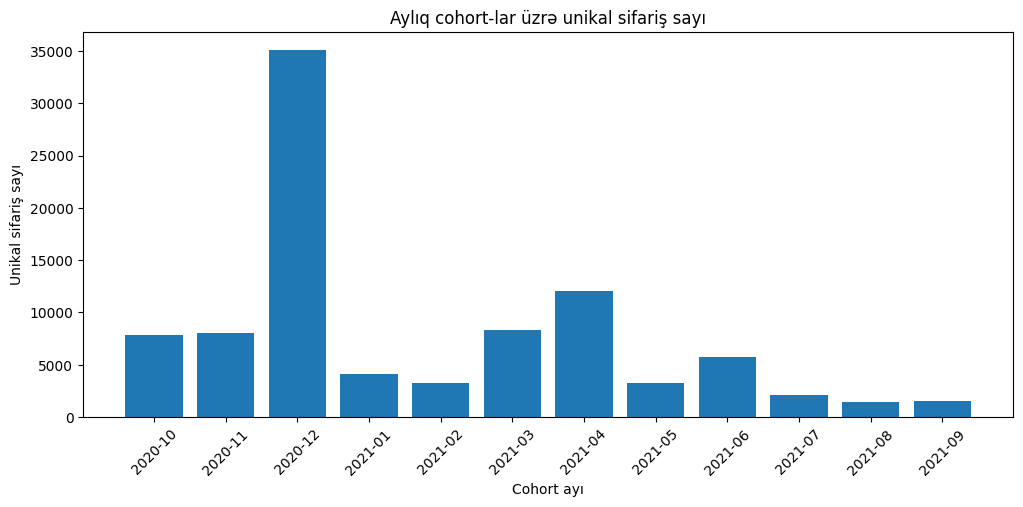

In [145]:
plt.figure(figsize=(12, 5))

plt.bar(
    cohort_summary['cohort_month'].astype(str),
    cohort_summary['unique_orders']
)

plt.title('Aylıq cohort-lar üzrə unikal sifariş sayı')
plt.xlabel('Cohort ayı')
plt.ylabel('Unikal sifariş sayı')

plt.xticks(rotation=45)

plt.show()

### Unikal sifariş qrafikinin şərhi

Qrafik aylıq cohort-lar üzrə unikal sifariş saylarının müqayisəsini göstərir.

Ən yüksək unikal sifariş sayı `2020-12` cohort-unda müşahidə olunur və təxminən 35 min sifariş təşkil edir.

`2021-04` cohort-u da digər aylara nisbətən yüksək sifariş sayı ilə seçilir.

2021-ci ilin son aylarına doğru isə unikal sifariş sayında ümumi azalma müşahidə olunur.

### Diqqət çəkən müşahidə

`2020-12` cohort-unda unikal sifariş sayı digər aylara nisbətən kəskin şəkildə yüksəkdir.

Bu göstərici ilkin baxışda anormal sıçrayış kimi görünür. Lakin həmin cohort-da unikal müştəri sayının da yüksək olması nəzərə alınmalıdır. Buna görə bu fərqin data səhvi deyil, cohort ölçüsünün və mövsümi satış artımının nəticəsi olması mümkündür.

Bu məqamı customer və revenue göstəriciləri ilə birlikdə müqayisə etmək daha düzgün nəticə çıxarmağa imkan verəcək.

### Aylıq cohort-lar üzrə unikal müştəri sayı

Hər aylıq cohort üzrə unikal müştəri sayını müqayisə etmək üçün bar chart yaradılır.

X oxunda cohort ayları, Y oxunda isə həmin cohort-a aid unikal müştərilərin sayı göstərilir.

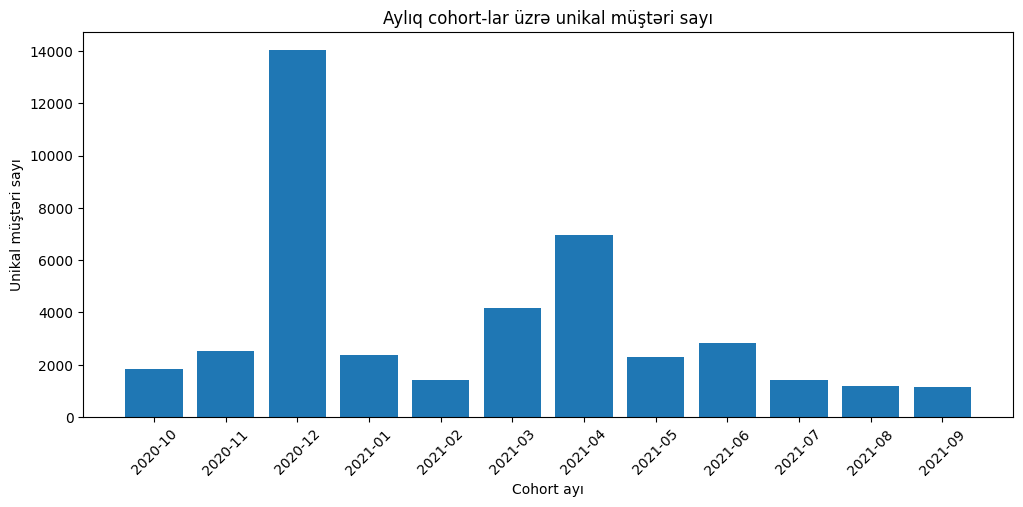

In [146]:
plt.figure(figsize=(12, 5))

plt.bar(
    cohort_summary['cohort_month'].astype(str),
    cohort_summary['unique_customers']
)

plt.title('Aylıq cohort-lar üzrə unikal müştəri sayı')
plt.xlabel('Cohort ayı')
plt.ylabel('Unikal müştəri sayı')

plt.xticks(rotation=45)

plt.show()

### Unikal müştəri qrafikinin şərhi

Qrafik aylıq cohort-lar üzrə unikal müştəri sayını göstərir.

Ən yüksək göstərici `2020-12` cohort-unda müşahidə olunur və bu cohort 14 020 unikal müştəridən ibarətdir. `2021-04` cohort-u da 6 968 müştəri ilə digər aylara nisbətən yüksək göstəriciyə malikdir.

Əvvəlki unikal sifariş qrafikində də `2020-12` cohort-unda kəskin artım müşahidə olunmuşdu. Müştəri sayının da həmin ayda yüksək olması göstərir ki, sifariş sayındakı artım yalnız anomaliya deyil, cohort-un böyük olması ilə əlaqəli ola bilər.

Bu artım mövsümi tələb, kampaniya və ya həmin dövrdə yeni müştəri sayının artması ilə bağlı ola bilər. Bunun dəqiq səbəbini müəyyən etmək üçün əlavə biznes məlumatı tələb olunur.

### Aylıq cohort-lar üzrə ümumi revenue

Hər aylıq cohort-un gətirdiyi ümumi gəliri müqayisə etmək üçün bar chart yaradılır.

Revenue dəyərləri böyük olduğu üçün qrafikdə milyon vahidində göstərilir. X oxunda cohort ayları, Y oxunda isə həmin cohort-un ümumi revenue göstəricisi göstərilir.

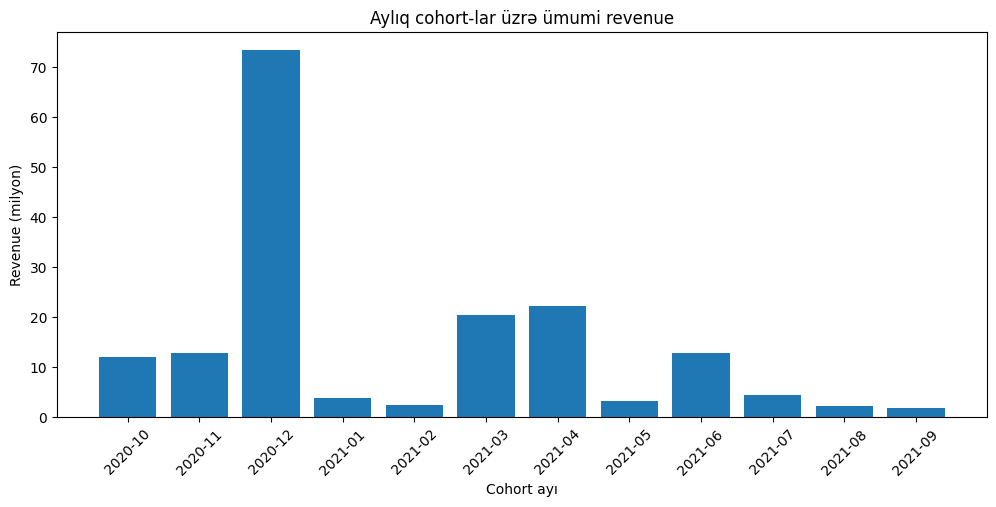

In [147]:
plt.figure(figsize=(12, 5))

plt.bar(
    cohort_summary['cohort_month'].astype(str),
    cohort_summary['total_revenue'] / 1_000_000
)

plt.title('Aylıq cohort-lar üzrə ümumi revenue')
plt.xlabel('Cohort ayı')
plt.ylabel('Revenue (milyon)')

plt.xticks(rotation=45)

plt.show()

### Revenue qrafikinin şərhi

Qrafik aylıq cohort-lar üzrə ümumi revenue göstəricilərini müqayisə edir.

Ən yüksək revenue `2020-12` cohort-unda müşahidə olunur və təxminən 73 milyon təşkil edir. `2021-03` və `2021-04` cohort-ları da digər aylara nisbətən yüksək revenue göstəricisinə malikdir.

Əvvəlki qrafiklərdə `2020-12` cohort-unda həm unikal sifariş, həm də unikal müştəri sayının yüksək olduğu görülmüşdü. Revenue göstəricisinin də həmin cohort-da ən yüksək olması bu cohort-un həm ölçü, həm də gəlir baxımından ən güclü cohort olduğunu göstərir.

2021-ci ilin son aylarına doğru isə revenue göstəricilərində ümumi azalma müşahidə olunur.

### Task 8. Customer activity pivot table

Sətirlərdə customer-in ilk sifariş ayı, sütunlarda isə sifariş ayı olacaq şəkildə unique customer saylarını göstərən pivot table yaradın. Nəticəni şərh edin.

### Cohort və sifariş ayı üzrə unikal müştəri sayının hesablanması

Müştərilərin zamanla aktivliyini görmək üçün data `cohort_month` və `order_month` üzrə qruplaşdırılır.

Hər qrup üçün unikal müştəri sayı `cust_id` sütunu üzərindən `nunique()` ilə hesablanır.

Beləliklə, hər cohort-a aid müştərilərdən müxtəlif aylarda neçə nəfərin alış etdiyi müəyyən edilir.

In [148]:
customer_activity = (
    sales_clean
    .groupby(['cohort_month', 'order_month'])['cust_id']
    .nunique()
    .reset_index(name='unique_customers')
)

In [149]:
customer_activity

,cohort_month,order_month,unique_customers
0,2020-10,2020-10,1822
1,2020-10,2020-11,306
2,2020-10,2020-12,381
3,2020-10,2021-01,169
4,2020-10,2021-02,123
...,...,...,...
73,2021-07,2021-08,95
74,2021-07,2021-09,52
75,2021-08,2021-08,1173
76,2021-08,2021-09,61


### Customer activity nəticəsinin yoxlanılması

Hər `cohort_month` və `order_month` kombinasiyası üzrə unikal müştəri sayı hesablandı.

Məsələn, `2020-10` cohort-unda ilk alış ayında 1822 müştəri aktiv olub. Həmin cohort-dan 306 müştəri 2020-ci ilin noyabrında, 381 müştəri isə dekabr ayında yenidən alış edib.

Bu nəticə müştərilərin ilk alış ayından sonra hansı aylarda aktiv olduğunu göstərir.

### Customer activity pivot table yaradılması

Hesablanmış müştəri aktivliyi pivot table formasına çevrilir.

Pivot cədvəldə:
- sətirlərdə `cohort_month`,
- sütunlarda `order_month`,
- dəyərlərdə isə `unique_customers`

göstərilir.

Bu struktur hər cohort-a aid müştərilərin sonrakı aylarda necə aktiv qaldığını daha rahat müqayisə etməyə imkan verir.

In [150]:
customer_pivot = customer_activity.pivot(
    index='cohort_month',
    columns='order_month',
    values='unique_customers'
)

In [151]:
customer_pivot

order_month,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09
cohort_month,,,,,,,,,,,,
2020-10,1822.0,306.0,381.0,169.0,123.0,177.0,151.0,88.0,143.0,85.0,54.0,80.0
2020-11,NaN,2522.0,562.0,211.0,135.0,204.0,178.0,106.0,188.0,82.0,47.0,82.0
2020-12,NaN,NaN,14020.0,1011.0,458.0,632.0,675.0,328.0,559.0,262.0,168.0,250.0
2021-01,NaN,NaN,NaN,2369.0,159.0,110.0,113.0,71.0,81.0,65.0,43.0,48.0
2021-02,NaN,NaN,NaN,NaN,1412.0,123.0,96.0,53.0,53.0,33.0,27.0,27.0
2021-03,NaN,NaN,NaN,NaN,NaN,4175.0,521.0,131.0,232.0,83.0,49.0,79.0
2021-04,NaN,NaN,NaN,NaN,NaN,NaN,6968.0,254.0,260.0,94.0,63.0,73.0
2021-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2305.0,159.0,89.0,49.0,40.0
2021-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2839.0,145.0,66.0,99.0


### Customer Activity Pivot Table

Bu pivot table müştərilərin ilk alış etdikləri aydan sonra hansı aylarda yenidən aktiv olduqlarını göstərir.

Sətirlərdə `cohort_month`, sütunlarda `order_month`, xanaların daxilində isə həmin ayda aktiv olan unikal müştəri sayı göstərilir.

Məsələn, `2020-10` cohort-u 1822 müştəridən ibarətdir. Bu cohort-dan 306 müştəri noyabrda, 381 müştəri dekabrda, 169 müştəri isə 2021-ci ilin yanvarında yenidən alış edib.

`NaN` dəyərləri həmin cohort-un hələ mövcud olmadığı əvvəlki aylarda aktivliyin mümkün olmadığını göstərir.

### Task 9. Aylıq cohort metric-ləri

Datanı ilk sifariş ayı və sifariş ayı üzrə qruplaşdıraraq hər qrup üçün total revenue və unique customer sayını hesablayın.

### Cohort və sifariş ayı üzrə ümumi revenue

Dataset `cohort_month` və `order_month` üzrə qruplaşdırılır.

Hər cohort-un hər sifariş ayında nə qədər ümumi gəlir gətirdiyini müəyyən etmək üçün `revenue` dəyərləri `sum()` vasitəsilə toplanır.

In [152]:
monthly_revenue = (sales_clean.groupby(['cohort_month', 'order_month'])['revenue'].sum())

In [153]:
monthly_revenue.reset_index()

,cohort_month,order_month,revenue
0,2020-10,2020-10,2.350822e+06
1,2020-10,2020-11,9.936032e+05
2,2020-10,2020-12,3.707018e+06
3,2020-10,2021-01,4.094837e+05
4,2020-10,2021-02,2.941921e+05
...,...,...,...
73,2021-07,2021-08,8.743780e+05
74,2021-07,2021-09,1.544950e+05
75,2021-08,2021-08,2.134201e+06
76,2021-08,2021-09,5.517513e+04


### Aylıq cohort revenue nəticəsinin yoxlanılması

Hər `cohort_month` və `order_month` kombinasiyası üzrə ümumi revenue hesablandı.

Nəticə hər cohort-a aid müştərilərin müxtəlif sifariş aylarında şirkətə nə qədər gəlir gətirdiyini göstərir.

Məsələn, `2020-10` cohort-u 2020-ci ilin oktyabr ayında təxminən 2.35 milyon, dekabr ayında isə təxminən 3.71 milyon revenue gətirib.

### Cohort və sifariş ayı üzrə unikal müştəri sayı

Dataset `cohort_month` və `order_month` üzrə qruplaşdırılır və hər qrupda neçə fərqli müştərinin aktiv olduğu hesablanır.

Eyni müştəri bir ay ərzində bir neçə sifariş verə bildiyi üçün `cust_id` sütununda `nunique()` istifadə olunur.

In [154]:
monthly_customers = (sales_clean.groupby(['cohort_month', 'order_month'])['cust_id'].nunique())

In [155]:
monthly_customers.reset_index()

,cohort_month,order_month,cust_id
0,2020-10,2020-10,1822
1,2020-10,2020-11,306
2,2020-10,2020-12,381
3,2020-10,2021-01,169
4,2020-10,2021-02,123
...,...,...,...
73,2021-07,2021-08,95
74,2021-07,2021-09,52
75,2021-08,2021-08,1173
76,2021-08,2021-09,61


### Aylıq unikal müştəri nəticəsinin yoxlanılması

Hər `cohort_month` və `order_month` kombinasiyası üzrə unikal müştəri sayı hesablandı.

Nəticə hər cohort-a aid müştərilərdən müxtəlif aylarda neçə nəfərin aktiv olduğunu göstərir.

Məsələn, `2020-10` cohort-unda ilk ay 1822 müştəri aktiv olub. Bu cohort-dan 306 müştəri noyabrda, 381 müştəri isə dekabrda alış edib.

In [156]:
monthly_customers = monthly_customers.reset_index(name='unique_customers')

In [157]:
monthly_customers

,cohort_month,order_month,unique_customers
0,2020-10,2020-10,1822
1,2020-10,2020-11,306
2,2020-10,2020-12,381
3,2020-10,2021-01,169
4,2020-10,2021-02,123
...,...,...,...
73,2021-07,2021-08,95
74,2021-07,2021-09,52
75,2021-08,2021-08,1173
76,2021-08,2021-09,61


### Aylıq revenue nəticəsinin cədvəl formasına salınması

Qruplaşdırmadan alınan revenue nəticəsi normal DataFrame formasına çevrilir.

Revenue sütunu `total_revenue` adlandırılır, çünki burada hər `cohort_month` və `order_month` kombinasiyası üzrə ümumi gəlir göstərilir.

In [158]:
monthly_revenue = monthly_revenue.reset_index(name='total_revenue')

In [159]:
monthly_revenue

,cohort_month,order_month,total_revenue
0,2020-10,2020-10,2.350822e+06
1,2020-10,2020-11,9.936032e+05
2,2020-10,2020-12,3.707018e+06
3,2020-10,2021-01,4.094837e+05
4,2020-10,2021-02,2.941921e+05
...,...,...,...
73,2021-07,2021-08,8.743780e+05
74,2021-07,2021-09,1.544950e+05
75,2021-08,2021-08,2.134201e+06
76,2021-08,2021-09,5.517513e+04


In [160]:
monthly_metrics=monthly_revenue.merge(monthly_customers,on=['cohort_month','order_month'])

In [161]:
monthly_metrics

,cohort_month,order_month,total_revenue,unique_customers
0,2020-10,2020-10,2.350822e+06,1822
1,2020-10,2020-11,9.936032e+05,306
2,2020-10,2020-12,3.707018e+06,381
3,2020-10,2021-01,4.094837e+05,169
4,2020-10,2021-02,2.941921e+05,123
...,...,...,...,...
73,2021-07,2021-08,8.743780e+05,95
74,2021-07,2021-09,1.544950e+05,52
75,2021-08,2021-08,2.134201e+06,1173
76,2021-08,2021-09,5.517513e+04,61


### Task 10. ARPU

Hər aylıq cohort və sifariş ayı üçün ARPU hesablayın. Nəticəni pivot table formasında göstərin.


# **ARPU = Average Revenue Per User , yəni bir aktiv müştəriyə düşən orta revenue.**

### ARPU göstəricisinin hesablanması

ARPU (Average Revenue Per User) hər aktiv müştəriyə düşən orta gəliri göstərir.

Hər `cohort_month` və `order_month` üçün ARPU ümumi revenue-nun həmin dövrdəki unikal müştəri sayına bölünməsi ilə hesablanır.

Formula:

`ARPU = total_revenue / unique_customers`

In [162]:
monthly_metrics['arpu']=(monthly_metrics['total_revenue']/monthly_metrics['unique_customers'])

### ARPU sütununun yaradılması

`monthly_metrics` cədvəlindəki `total_revenue` hər cohort və sifariş ayı üzrə `unique_customers` sayına bölünür.

Nəticə `arpu` adlı yeni sütunda saxlanılır. Bu göstərici həmin dövrdə bir aktiv müştərinin orta hesabla nə qədər revenue gətirdiyini göstərir.

In [163]:
monthly_metrics

,cohort_month,order_month,total_revenue,unique_customers,arpu
0,2020-10,2020-10,2.350822e+06,1822,1290.242532
1,2020-10,2020-11,9.936032e+05,306,3247.069418
2,2020-10,2020-12,3.707018e+06,381,9729.707295
3,2020-10,2021-01,4.094837e+05,169,2422.980586
4,2020-10,2021-02,2.941921e+05,123,2391.805415
...,...,...,...,...,...
73,2021-07,2021-08,8.743780e+05,95,9203.979147
74,2021-07,2021-09,1.544950e+05,52,2971.056769
75,2021-08,2021-08,2.134201e+06,1173,1819.438602
76,2021-08,2021-09,5.517513e+04,61,904.510393


### ARPU nəticəsinin yoxlanılması

`monthly_metrics` cədvəlində hər `cohort_month` və `order_month` üzrə ümumi revenue, unikal müştəri sayı və ARPU birlikdə göstərilir.

ARPU ümumi revenue-nun həmin dövrdə aktiv olan unikal müştəri sayına bölünməsi ilə hesablanır.

Məsələn, `2020-10` cohort-u ilk ayında 1822 aktiv müştəri ilə təxminən 2.35 milyon revenue gətirib və ARPU təxminən 1290.24 olub.

### ARPU pivot table yaradılması

ARPU göstəricilərini cohort-lar və sifariş ayları üzrə daha rahat müqayisə etmək üçün pivot table yaradılır.

Pivot cədvəldə:
- sətirlərdə `cohort_month`,
- sütunlarda `order_month`,
- xanaların daxilində isə `arpu` göstəricisi yerləşdirilir.

In [164]:
arpu_pivot = monthly_metrics.pivot(
    index='cohort_month',
    columns='order_month',
    values='arpu'
)

In [165]:
arpu_pivot

order_month,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09
cohort_month,,,,,,,,,,,,
2020-10,1290.242532,3247.069418,9729.707295,2422.980586,2391.805415,8904.126946,8148.851265,2320.002636,4306.992596,2232.627353,1720.704870,4427.932212
2020-11,NaN,1800.336573,6390.708760,2092.490744,2329.321930,6524.344324,5800.671343,2254.335255,4155.674503,2483.749976,1629.520489,4003.132951
2020-12,NaN,NaN,4078.350329,1333.517461,2040.058941,8168.866608,6462.669759,1757.577299,4498.161422,1376.225038,1160.992411,2899.964448
2021-01,NaN,NaN,NaN,1096.809299,1061.536805,1689.947218,2251.115069,1890.496915,1778.664630,2663.769923,1055.948256,1104.509292
2021-02,NaN,NaN,NaN,NaN,971.795291,2969.730114,2422.545542,2364.367943,3511.027396,2714.331667,2015.817778,2867.176667
2021-03,NaN,NaN,NaN,NaN,NaN,3563.627623,6137.490246,2605.776710,6195.633616,2125.830120,1140.330000,5198.289785
2021-04,NaN,NaN,NaN,NaN,NaN,NaN,2829.937359,1348.662433,6032.994825,1623.523032,1502.923016,4967.688370
2021-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1044.757595,3038.561283,1774.077730,1186.028837,1656.541200
2021-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3810.628795,5634.719945,9294.037727,5009.815192


### ARPU pivot table nəticəsinin şərhi

ARPU pivot table hər aylıq cohort-un müxtəlif sifariş aylarında bir aktiv müştəriyə düşən orta revenue göstəricisini göstərir.

Sətirlərdə `cohort_month`, sütunlarda `order_month`, xanaların daxilində isə ARPU dəyərləri yerləşir.

Məsələn, `2020-10` cohort-unun ilk ayda ARPU-su təxminən 1290.24, noyabr ayında 3247.07, dekabr ayında isə 9729.71 olmuşdur.

ARPU-nun aylara görə dəyişməsi həmin dövrdə aktiv olan müştərilərin orta gəlir yaratma səviyyəsinin dəyişdiyini göstərir. `NaN` dəyərləri isə həmin cohort-un hələ mövcud olmadığı əvvəlki aylara aiddir.

### Task 11 — Aylıq Cohort Lifetime

Hər sifarişin müştərinin ilk alış ayından neçə ay sonra baş verdiyini müəyyən etmək üçün `cohort_lifetime` dəyişəni yaradılır.

Müştərinin ilk alış etdiyi ay `lifetime = 0` kimi qəbul edilir. Sonrakı aylar isə ilk alış ayından keçən ayların sayını göstərir.

In [166]:
sales_clean['cohort_lifetime'] = ((sales_clean['order_month'].dt.year - sales_clean['cohort_month'].dt.year) * 12
    + (sales_clean['order_month'].dt.month - sales_clean['cohort_month'].dt.month)
)

In [167]:
sales_clean

,order_id,order_date,status,cust_id,item_id,qty_ordered,price,discount_amount,category,payment_method,revenue,first_order_date,cohort_month,order_month,cohort_lifetime
0,100354678,2020-10-01,received,60124,574772,21,89.9,0.0,Men's Fashion,cod,1887.9,2020-10-01,2020-10,2020-10,0
1,100354678,2020-10-01,received,60124,574774,11,19.0,0.0,Men's Fashion,cod,209.0,2020-10-01,2020-10,2020-10,0
2,100354680,2020-10-01,complete,60124,574777,9,149.9,0.0,Men's Fashion,cod,1349.1,2020-10-01,2020-10,2020-10,0
3,100354680,2020-10-01,complete,60124,574779,9,79.9,0.0,Men's Fashion,cod,719.1,2020-10-01,2020-10,2020-10,0
4,100367357,2020-11-13,received,60124,595185,2,99.9,0.0,Men's Fashion,cod,199.8,2020-10-01,2020-10,2020-11,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286355,100562293,2021-09-29,paid,115304,905066,2,24.5,0.0,Mobiles & Tablets,bankalfalah,49.0,2021-09-29,2021-09,2021-09,0
286356,100562293,2021-09-29,paid,115304,905067,2,15.0,0.0,Mobiles & Tablets,bankalfalah,30.0,2021-09-29,2021-09,2021-09,0
286374,100562338,2021-09-30,paid,115317,905145,2,99.9,0.0,Women's Fashion,bankalfalah,199.8,2021-09-30,2021-09,2021-09,0
286382,100562352,2021-09-30,paid,23611,905161,2,57.2,0.0,Beauty & Grooming,bankalfalah,114.4,2021-09-30,2021-09,2021-09,0


### Cohort lifetime hesablanmasının izahı

Bu kod hər sifarişin müştərinin ilk alış ayından neçə ay sonra baş verdiyini hesablamaq üçün istifadə olunur.

Əvvəlcə `order_month` və `cohort_month` sütunlarından il fərqi tapılır:

`order_month ili - cohort_month ili`

İl fərqi ayla ifadə etmək üçün `12`-yə vurulur.

Daha sonra ay fərqi hesablanır:

`order_month ayı - cohort_month ayı`

Sonda il fərqindən gələn ay sayı ilə ay fərqi toplanır və nəticə `cohort_lifetime` sütununda saxlanılır.

Məsələn:

`cohort_month = 2020-10`  
`order_month = 2021-01`

İl fərqi:

`2021 - 2020 = 1`

Aya çevirdikdə:

`1 × 12 = 12 ay`

Ay fərqi:

`1 - 10 = -9`

Son nəticə:

`12 + (-9) = 3`

Deməli, bu sifariş müştərinin ilk alış ayından **3 ay sonra** baş verib.

Beləliklə:

- ilk alış ayı → `cohort_lifetime = 0`
- 1 ay sonra → `cohort_lifetime = 1`
- 2 ay sonra → `cohort_lifetime = 2`
- 3 ay sonra → `cohort_lifetime = 3`

`.dt.year` tarixdən ili, `.dt.month` isə ayı götürmək üçün istifadə olunur.

### Task 12. ARPU heatmap

Sətirlərdə aylıq cohort, sütunlarda `cohort_lifetime`, dəyər kimi ARPU olan pivot table yaradın və heatmap ilə vizuallaşdırın. Nəticəni şərh edin.

### ARPU analizi üçün cohort lifetime yaradılması

ARPU göstəricilərini müştərinin ilk alışından keçən ay sayına görə müqayisə etmək üçün `monthly_metrics` cədvəlində `cohort_lifetime` dəyişəni yaradılır.

`cohort_lifetime` sifariş ayının cohort ayından neçə ay sonra baş verdiyini göstərir.

İlk alış ayı `0`, bir ay sonrası `1`, iki ay sonrası `2` kimi qəbul edilir.

In [168]:
monthly_metrics['cohort_lifetime'] = (
    (monthly_metrics['order_month'].dt.year - monthly_metrics['cohort_month'].dt.year) * 12
    + (monthly_metrics['order_month'].dt.month - monthly_metrics['cohort_month'].dt.month)
)

In [169]:
monthly_metrics[
    ['cohort_month', 'order_month', 'cohort_lifetime', 'arpu']
].head(10)

,cohort_month,order_month,cohort_lifetime,arpu
0,2020-10,2020-10,0,1290.242532
1,2020-10,2020-11,1,3247.069418
2,2020-10,2020-12,2,9729.707295
3,2020-10,2021-01,3,2422.980586
4,2020-10,2021-02,4,2391.805415
5,2020-10,2021-03,5,8904.126946
6,2020-10,2021-04,6,8148.851265
7,2020-10,2021-05,7,2320.002636
8,2020-10,2021-06,8,4306.992596
9,2020-10,2021-07,9,2232.627353


### Cohort lifetime və ARPU nəticəsinin yoxlanılması

`cohort_month`, `order_month`, `cohort_lifetime` və `arpu` birlikdə göstərilərək hesablamanın düzgünlüyü yoxlanılır.

Beləliklə, hər cohort-un ilk alış ayından neçə ay sonra hansı ARPU göstəricisinə malik olduğu müşahidə edilir.

In [170]:
arpu_lifetime_pivot = monthly_metrics.pivot(
    index='cohort_month',
    columns='cohort_lifetime',
    values='arpu'
)

In [171]:
arpu_lifetime_pivot

cohort_lifetime,0,1,2,3,4,5,6,7,8,9,10,11
cohort_month,,,,,,,,,,,,
2020-10,1290.242532,3247.069418,9729.707295,2422.980586,2391.805415,8904.126946,8148.851265,2320.002636,4306.992596,2232.627353,1720.704870,4427.932212
2020-11,1800.336573,6390.708760,2092.490744,2329.321930,6524.344324,5800.671343,2254.335255,4155.674503,2483.749976,1629.520489,4003.132951,NaN
2020-12,4078.350329,1333.517461,2040.058941,8168.866608,6462.669759,1757.577299,4498.161422,1376.225038,1160.992411,2899.964448,NaN,NaN
2021-01,1096.809299,1061.536805,1689.947218,2251.115069,1890.496915,1778.664630,2663.769923,1055.948256,1104.509292,NaN,NaN,NaN
2021-02,971.795291,2969.730114,2422.545542,2364.367943,3511.027396,2714.331667,2015.817778,2867.176667,NaN,NaN,NaN,NaN
2021-03,3563.627623,6137.490246,2605.776710,6195.633616,2125.830120,1140.330000,5198.289785,NaN,NaN,NaN,NaN,NaN
2021-04,2829.937359,1348.662433,6032.994825,1623.523032,1502.923016,4967.688370,NaN,NaN,NaN,NaN,NaN,NaN
2021-05,1044.757595,3038.561283,1774.077730,1186.028837,1656.541200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-06,3810.628795,5634.719945,9294.037727,5009.815192,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### ARPU heatmap yaradılması

Aylıq cohort-ların lifetime dövrləri üzrə ARPU göstəricilərini daha rahat müqayisə etmək üçün heatmap yaradılır.

Heatmap-də:
- Y oxunda `cohort_month`,
- X oxunda `cohort_lifetime`,
- xanaların daxilində isə ARPU dəyərləri göstərilir.

Rəng intensivliyi ARPU-nun aşağı və ya yüksək olduğunu vizual şəkildə müqayisə etməyə kömək edir.

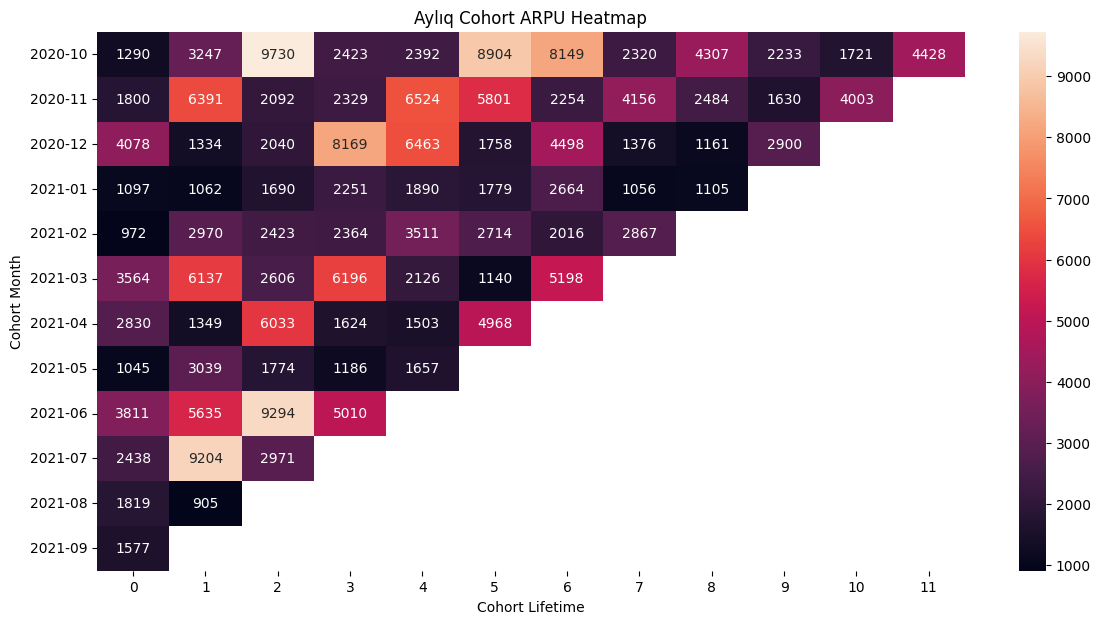

In [172]:
plt.figure(figsize=(14, 7))

sns.heatmap(
    arpu_lifetime_pivot,
    annot=True,
    fmt='.0f'
)

plt.title('Aylıq Cohort ARPU Heatmap')
plt.xlabel('Cohort Lifetime')
plt.ylabel('Cohort Month')

plt.show()

### ARPU Heatmap nəticəsinin şərhi

Heatmap aylıq cohort-ların müxtəlif lifetime dövrlərində bir aktiv müştəriyə düşən orta revenue göstəricisini göstərir.

ARPU dəyərlərinin cohort və lifetime üzrə sabit olmadığı, bəzi dövrlərdə nəzərəçarpacaq dərəcədə yüksəldiyi müşahidə olunur.

Məsələn, `2020-10` cohort-unda `lifetime = 2` zamanı ARPU təxminən 9730 ilə yüksək göstəriciyə çatıb. `2021-06` cohort-unda `lifetime = 2` üçün təxminən 9294, `2021-07` cohort-unda isə `lifetime = 1` üçün təxminən 9204 ARPU müşahidə olunur.

Yüksək ARPU həmin dövrdə aktiv olan müştərilərin orta hesabla daha çox revenue gətirdiyini göstərir. Bu, həmin dövrdə müştəri sayının yüksək olması demək deyil.

Cədvəlin üçbucaq formasında olması yeni cohort-ların hələ bütün lifetime dövrlərinə çatmaması ilə əlaqədardır. Buna görə daha yeni cohort-lar üçün uzunmüddətli ARPU nəticələri hələ mövcud deyil.

## 3. Həftəlik retention analysis

### Task 13. Həftəlik period-lar

Hər sifariş üçün sifarişin baş verdiyi həftənin başlanğıc tarixini, hər customer üçün isə ilk alış həftəsinin başlanğıc tarixini hesablayın.


### Sifariş həftəsinin yaradılması

Hər sifarişin hansı həftədə baş verdiyini müəyyən etmək üçün `order_date` sütunu həftəlik period formatına çevrilir.

Həftənin başlanğıc tarixi götürülərək `order_week` adlı yeni dəyişən yaradılır.

Bu dəyişən sonrakı həftəlik retention analizində hər sifarişin hansı həftəyə aid olduğunu müəyyən etmək üçün istifadə olunacaq.

In [173]:
sales_clean['order_week'] = (sales_clean['order_date'].dt.to_period('W').dt.start_time)

In [174]:
sales_clean.sample(n=10 , replace=False)

,order_id,order_date,status,cust_id,item_id,qty_ordered,price,discount_amount,category,payment_method,revenue,first_order_date,cohort_month,order_month,cohort_lifetime,order_week
51106,100368053,2020-11-15,complete,63322,596325,5,85.0,68.000,Superstore,Payaxis,357.000,2020-11-15,2020-11,2020-11,0,2020-11-09
127160,100406972,2020-12-25,complete,74962,663835,2,99.9,0.000,Men's Fashion,cod,199.800,2020-12-25,2020-12,2020-12,0,2020-12-21
31188,100373077,2020-11-28,complete,43855,603643,3,20.1,0.000,Superstore,cod,60.300,2020-10-30,2020-10,2020-11,1,2020-11-23
127787,100407493,2020-12-25,complete,2778,664873,2,24.8,0.000,Kids & Baby,cod,49.600,2020-12-25,2020-12,2020-12,0,2020-12-21
73359,100424685,2020-12-28,complete,66252,693705,2,1369.8,271.980,Mobiles & Tablets,Easypay_MA,2467.620,2020-12-13,2020-12,2020-12,0,2020-12-28
145119,100419751,2020-12-27,complete,78781,684703,2,87.2,0.000,Home & Living,cod,174.400,2020-12-27,2020-12,2020-12,0,2020-12-21
232995,100498727,2021-04-29,received,100087,807164,6,200.0,0.000,Others,Easypay,1200.000,2021-04-29,2021-04,2021-04,0,2021-04-26
110889,100396812,2020-12-22,received,71739,645662,2,69.9,0.000,Men's Fashion,cod,139.800,2020-12-22,2020-12,2020-12,0,2020-12-21
268559,100553517,2021-08-29,received,6451,890008,6,79.5,59.625,Superstore,bankalfalah,417.375,2021-07-04,2021-07,2021-08,1,2021-08-23
186400,100452332,2021-03-18,complete,87457,743810,11,139.9,0.000,Men's Fashion,cod,1538.900,2021-03-18,2021-03,2021-03,0,2021-03-15


### `order_week` nəticəsinin yoxlanılması

Datasetdən təsadüfi 10 sətir seçilərək yaradılmış `order_week` sütunu yoxlanıldı.

`order_date` konkret sifariş tarixini, `order_week` isə həmin sifarişin aid olduğu həftənin başlanğıc tarixini göstərir.

Məsələn, `order_date = 2020-11-22` olduqda `order_week = 2020-11-16` göstərilir. Bu o deməkdir ki, 22 noyabr tarixində verilmiş sifariş 16 noyabrda başlayan həftəyə aiddir.

Başqa bir nümunədə `order_date = 2021-05-05`, `order_week = 2021-05-03` olmuşdur. Yəni həmin sifariş 3 mayda başlayan həftəyə daxil edilir.

Beləliklə, bütün sifarişlər konkret günlərə görə deyil, aid olduqları həftələr üzrə qruplaşdırıla biləcək.

### Müştərinin ilk alış həftəsinin yaradılması

Həftəlik cohort analysis üçün hər müştərinin ilk alış etdiyi həftə müəyyən edilir.

Bu məqsədlə `first_order_date` sütunu həftəlik period formatına çevrilir və həmin həftənin başlanğıc tarixi götürülür.

Yaradılan `cohort_week` sütunu hər müştərinin hansı həftəlik cohort-a aid olduğunu göstərir.

In [175]:
sales_clean['cohort_week']=(sales_clean['first_order_date'].dt.to_period('W').dt.start_time)

In [176]:
sales_clean

,order_id,order_date,status,cust_id,item_id,qty_ordered,price,discount_amount,category,payment_method,revenue,first_order_date,cohort_month,order_month,cohort_lifetime,order_week,cohort_week
0,100354678,2020-10-01,received,60124,574772,21,89.9,0.0,Men's Fashion,cod,1887.9,2020-10-01,2020-10,2020-10,0,2020-09-28,2020-09-28
1,100354678,2020-10-01,received,60124,574774,11,19.0,0.0,Men's Fashion,cod,209.0,2020-10-01,2020-10,2020-10,0,2020-09-28,2020-09-28
2,100354680,2020-10-01,complete,60124,574777,9,149.9,0.0,Men's Fashion,cod,1349.1,2020-10-01,2020-10,2020-10,0,2020-09-28,2020-09-28
3,100354680,2020-10-01,complete,60124,574779,9,79.9,0.0,Men's Fashion,cod,719.1,2020-10-01,2020-10,2020-10,0,2020-09-28,2020-09-28
4,100367357,2020-11-13,received,60124,595185,2,99.9,0.0,Men's Fashion,cod,199.8,2020-10-01,2020-10,2020-11,1,2020-11-09,2020-09-28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286355,100562293,2021-09-29,paid,115304,905066,2,24.5,0.0,Mobiles & Tablets,bankalfalah,49.0,2021-09-29,2021-09,2021-09,0,2021-09-27,2021-09-27
286356,100562293,2021-09-29,paid,115304,905067,2,15.0,0.0,Mobiles & Tablets,bankalfalah,30.0,2021-09-29,2021-09,2021-09,0,2021-09-27,2021-09-27
286374,100562338,2021-09-30,paid,115317,905145,2,99.9,0.0,Women's Fashion,bankalfalah,199.8,2021-09-30,2021-09,2021-09,0,2021-09-27,2021-09-27
286382,100562352,2021-09-30,paid,23611,905161,2,57.2,0.0,Beauty & Grooming,bankalfalah,114.4,2021-09-30,2021-09,2021-09,0,2021-09-27,2021-09-27


### Task 13 — Nümunə sətirlərin izahı

1. `order_date = 2020-10-01`, `order_week = 2020-09-28`, `cohort_week = 2020-09-28`

Bu sətirdə sifariş 1 oktyabr tarixində verilib və həmin tarix 28 sentyabrda başlayan həftəyə düşür. `order_week` və `cohort_week` eyni olduğu üçün bu sifariş müştərinin ilk alış həftəsinə aiddir.

2. `order_date = 2020-11-13`, `order_week = 2020-11-09`, `cohort_week = 2020-09-28`

Burada müştərinin ilk alış həftəsi 28 sentyabrda başlayıb, baxdığımız sifariş isə 9 noyabrda başlayan həftədə baş verib. Bu, müştərinin ilk alış həftəsindən sonra yenidən alış etdiyini göstərir.

3. `order_date = 2021-09-30`, `order_week = 2021-09-27`, `cohort_week = 2021-09-27`

Bu sətirdə sifariş tarixi 30 sentyabrdır və həmin tarix 27 sentyabrda başlayan həftəyə düşür. `order_week` və `cohort_week` eyni olduğu üçün bu sifariş müştərinin ilk alış həftəsinə aiddir.

### Task 14. Həftəlik cohort lifetime

Hər sifarişin customer-in ilk alış həftəsindən neçə həftə sonra baş verdiyini göstərən həftəlik `cohort_lifetime` yaradın.

# Burada məqsəd : Müştərinin ilk alış həftəsindən konkret sifariş həftəsinə qədər neçə həftə keçib?

In [177]:
sales_clean['weekly_lifetime'] = ((sales_clean['order_week'] - sales_clean['cohort_week']).dt.days // 7)

In [178]:
sales_clean

,order_id,order_date,status,cust_id,item_id,qty_ordered,price,discount_amount,category,payment_method,revenue,first_order_date,cohort_month,order_month,cohort_lifetime,order_week,cohort_week,weekly_lifetime
0,100354678,2020-10-01,received,60124,574772,21,89.9,0.0,Men's Fashion,cod,1887.9,2020-10-01,2020-10,2020-10,0,2020-09-28,2020-09-28,0
1,100354678,2020-10-01,received,60124,574774,11,19.0,0.0,Men's Fashion,cod,209.0,2020-10-01,2020-10,2020-10,0,2020-09-28,2020-09-28,0
2,100354680,2020-10-01,complete,60124,574777,9,149.9,0.0,Men's Fashion,cod,1349.1,2020-10-01,2020-10,2020-10,0,2020-09-28,2020-09-28,0
3,100354680,2020-10-01,complete,60124,574779,9,79.9,0.0,Men's Fashion,cod,719.1,2020-10-01,2020-10,2020-10,0,2020-09-28,2020-09-28,0
4,100367357,2020-11-13,received,60124,595185,2,99.9,0.0,Men's Fashion,cod,199.8,2020-10-01,2020-10,2020-11,1,2020-11-09,2020-09-28,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286355,100562293,2021-09-29,paid,115304,905066,2,24.5,0.0,Mobiles & Tablets,bankalfalah,49.0,2021-09-29,2021-09,2021-09,0,2021-09-27,2021-09-27,0
286356,100562293,2021-09-29,paid,115304,905067,2,15.0,0.0,Mobiles & Tablets,bankalfalah,30.0,2021-09-29,2021-09,2021-09,0,2021-09-27,2021-09-27,0
286374,100562338,2021-09-30,paid,115317,905145,2,99.9,0.0,Women's Fashion,bankalfalah,199.8,2021-09-30,2021-09,2021-09,0,2021-09-27,2021-09-27,0
286382,100562352,2021-09-30,paid,23611,905161,2,57.2,0.0,Beauty & Grooming,bankalfalah,114.4,2021-09-30,2021-09,2021-09,0,2021-09-27,2021-09-27,0


### Həftəlik cohort lifetime nəticəsinin yoxlanılması

`weekly_lifetime` sütunu yoxlanıldı və hər sifarişin müştərinin ilk alış həftəsindən neçə həftə sonra baş verdiyi müəyyən edildi.

Əgər `order_week` və `cohort_week` eynidirsə, `weekly_lifetime = 0` olur və bu sifariş müştərinin ilk alış həftəsinə aiddir.

Məsələn, `cohort_week = 2020-09-28` və `order_week = 2020-11-09` olduqda arada 42 gün, yəni 6 həftə fərq var. Buna görə `weekly_lifetime = 6` hesablanır.

### Həftəlik cohort sütunlarının izahı

`cohort_week` — müştərinin ilk alış etdiyi həftənin başlanğıc tarixini göstərir. Bu sütun müştərinin hansı həftəlik cohort-a aid olduğunu müəyyən edir.

`order_week` — hər konkret sifarişin baş verdiyi həftənin başlanğıc tarixini göstərir.

`weekly_lifetime` — `order_week` ilə `cohort_week` arasındakı həftə fərqini göstərir. Yəni sifarişin müştərinin ilk alış həftəsindən neçə həftə sonra baş verdiyini bildirir.

Məsələn, `cohort_week = 2020-09-28`, `order_week = 2020-11-09` və `weekly_lifetime = 6` olduqda, bu müştərinin ilk alış həftəsindən 6 həftə sonra yenidən alış etdiyini göstərir.

### Task 15. Həftəlik active customer-lər

Datanı ilk alış həftəsi və həftəlik `cohort_lifetime` üzrə qruplaşdıraraq hər qrup üçün unique active customer sayını hesablayın.

# Hər həftəlik cohort-da, hər weekly_lifetime dövründə neçə unikal müştəri aktiv olub?

### Task 15 — Həftəlik aktiv müştərilərin hesablanması

Müştərilərin həftələr üzrə aktivliyini müəyyən etmək üçün data `cohort_week` və `weekly_lifetime` üzrə qruplaşdırılır.

Hər qrupda neçə fərqli müştərinin aktiv olduğunu hesablamaq üçün `cust_id` sütununda `nunique()` istifadə olunur.

Beləliklə, hər həftəlik cohort-un ilk alış həftəsindən sonrakı həftələrdə neçə unikal müştərinin alış etdiyi müəyyən edilir.

In [179]:
weekly_active_customers = (sales_clean.groupby(['cohort_week', 'weekly_lifetime'])['cust_id'].nunique())

In [180]:
weekly_active_customers.reset_index()

,cohort_week,weekly_lifetime,cust_id
0,2020-09-28,0,402
1,2020-09-28,1,23
2,2020-09-28,2,25
3,2020-09-28,3,25
4,2020-09-28,4,14
...,...,...,...
1364,2021-09-13,1,9
1365,2021-09-13,2,2
1366,2021-09-20,0,160
1367,2021-09-20,1,2


### Həftəlik aktiv müştəri nəticəsinin cədvəl formasına salınması

Hər `cohort_week` və `weekly_lifetime` üzrə hesablanan unikal müştəri sayı normal DataFrame formasına çevrilir.

Hesablanan dəyərlər müştəri ID-si deyil, aktiv unikal müştəri sayı olduğu üçün nəticə sütunu `active_customers` adlandırılır.

In [181]:
weekly_active_customers = weekly_active_customers.reset_index(name='active_customers')

In [182]:
weekly_active_customers

,cohort_week,weekly_lifetime,active_customers
0,2020-09-28,0,402
1,2020-09-28,1,23
2,2020-09-28,2,25
3,2020-09-28,3,25
4,2020-09-28,4,14
...,...,...,...
1364,2021-09-13,1,9
1365,2021-09-13,2,2
1366,2021-09-20,0,160
1367,2021-09-20,1,2


### Həftəlik aktiv müştəri nəticəsinin şərhi

Cədvəldə hər `cohort_week` üzrə müxtəlif `weekly_lifetime` dövrlərində aktiv olan unikal müştərilərin sayı göstərilir.

- `cohort_week` — müştərinin ilk alış etdiyi həftəni göstərir.
- `weekly_lifetime` — ilk alış həftəsindən neçə həftə keçdiyini göstərir.
- `active_customers` — həmin həftədə alış edən unikal müştərilərin sayıdır.

Məsələn, `2020-09-28` cohort-u üçün `weekly_lifetime = 0` zamanı 402 aktiv müştəri var. Bu, həmin cohort-un başlanğıc ölçüsüdür.

Bir həftə sonra (`weekly_lifetime = 1`) 23 müştəri, iki həftə sonra (`weekly_lifetime = 2`) isə 25 müştəri aktiv olub.

Aktiv müştəri sayının hər həftə mütləq azalması tələb olunmur. Məsələn, birinci həftədə alış etməyən bəzi müştərilər ikinci və ya daha sonrakı həftələrdə yenidən alış edə bilər.

### Task 16 — Initial Cohort Size  yəni cohort-un başlanğıcdakı müştəri sayıdır

Hər həftəlik cohort-un başlanğıc ölçüsünü müəyyən etmək üçün `weekly_lifetime = 0` olan sətirlər seçilir.

`weekly_lifetime = 0` müştərilərin ilk alış həftəsini göstərir. Buna görə həmin sətirdəki `active_customers` dəyəri cohort-un ilkin müştəri sayı hesab olunur.




# Burada məqsəd hər həftəlik cohort-un başlanğıcda neçə müştəridən ibarət olduğunu tapmaqdır.

In [183]:
initial_cohort_size = weekly_active_customers[weekly_active_customers['weekly_lifetime']==0 ][['cohort_week', 'active_customers']]

In [184]:
initial_cohort_size

,cohort_week,active_customers
0,2020-09-28,402
52,2020-10-05,441
103,2020-10-12,342
153,2020-10-19,397
202,2020-10-26,246
249,2020-11-02,427
295,2020-11-09,1007
341,2020-11-16,603
386,2020-11-23,440
430,2020-11-30,463


### Initial cohort size sütununun adlandırılması

`weekly_lifetime = 0` olan müştəri sayı hər cohort-un başlanğıc ölçüsünü göstərir.

Buna görə `active_customers` sütununun adı daha aydın olması üçün `initial_cohort_size` olaraq dəyişdirilir.


In [185]:
initial_cohort_size = initial_cohort_size.rename(columns={'active_customers': 'initial_cohort_size'})

### Initial cohort size məlumatının həftəlik cohort cədvəlinə əlavə edilməsi

Hər cohort-un başlanğıc müştəri sayı `weekly_active_customers` cədvəlinə əlavə olunur.

Birləşdirmə `cohort_week` sütununa əsasən aparılır. Beləliklə, hər `weekly_lifetime` sətrində həm həmin həftədə aktiv olan müştəri sayı, həm də cohort-un ilkin ölçüsü birlikdə göstərilir.

Bu məlumat növbəti mərhələdə retention rate hesablamaq üçün istifadə olunacaq.

In [186]:
weekly_active_customers = weekly_active_customers.merge(initial_cohort_size,on='cohort_week')

In [187]:
weekly_active_customers

,cohort_week,weekly_lifetime,active_customers,initial_cohort_size
0,2020-09-28,0,402,402
1,2020-09-28,1,23,402
2,2020-09-28,2,25,402
3,2020-09-28,3,25,402
4,2020-09-28,4,14,402
...,...,...,...,...
1364,2021-09-13,1,9,495
1365,2021-09-13,2,2,495
1366,2021-09-20,0,160,160
1367,2021-09-20,1,2,160


### Initial cohort size nəticəsinin yoxlanılması

`initial_cohort_size` hər həftəlik cohort-un başlanğıcdakı müştəri sayını göstərir.

Məsələn, `2020-09-28` cohort-u `weekly_lifetime = 0` zamanı 402 müştəridən ibarətdir. Sonrakı həftələrdə aktiv müştəri sayı dəyişsə də, müqayisə üçün başlanğıc cohort ölçüsü 402 olaraq saxlanılır.

Bu məlumat növbəti mərhələdə retention rate hesablamaq üçün istifadə olunacaq.

### Task 17 — Retention Rate

Retention rate hər cohort-un başlanğıcdakı müştərilərindən müəyyən həftədə neçə faizinin yenidən aktiv olduğunu göstərir.

Retention rate həmin həftədəki aktiv müştəri sayının cohort-un ilkin müştəri sayına bölünməsi ilə hesablanır.

Formula:

`retention_rate = active_customers / initial_cohort_size`

In [188]:
weekly_active_customers['retention_rate'] = ( weekly_active_customers['active_customers'] / weekly_active_customers['initial_cohort_size'])

In [189]:
weekly_active_customers

,cohort_week,weekly_lifetime,active_customers,initial_cohort_size,retention_rate
0,2020-09-28,0,402,402,1.000000
1,2020-09-28,1,23,402,0.057214
2,2020-09-28,2,25,402,0.062189
3,2020-09-28,3,25,402,0.062189
4,2020-09-28,4,14,402,0.034826
...,...,...,...,...,...
1364,2021-09-13,1,9,495,0.018182
1365,2021-09-13,2,2,495,0.004040
1366,2021-09-20,0,160,160,1.000000
1367,2021-09-20,1,2,160,0.012500


### Active customers və initial cohort size fərqi

`initial_cohort_size` hər cohort-un başlanğıcdakı ümumi müştəri sayını göstərir və həmin cohort üçün dəyişmir.

`active_customers` isə həmin başlanğıc qrupdan konkret həftədə yenidən aktiv olan müştərilərin sayını göstərir.

Məsələn, başlanğıcda 402 müştəri olan cohort-da 4 həftə sonra 14 müştəri aktiv olub. Buna görə retention rate `14 / 402 ≈ 3.48%` olur.

### Retention rate nəticəsinin şərhi

Retention rate hər cohort-un başlanğıcdakı müştərilərindən müəyyən həftədə neçə faizinin yenidən aktiv olduğunu göstərir.

`weekly_lifetime = 0` zamanı retention rate `1.0`, yəni 100%-dir. Bunun səbəbi ilk həftədə bütün cohort üzvlərinin başlanğıc qrupunda olmasıdır.

Məsələn, `2020-09-28` cohort-u 402 müştəridən ibarətdir. Bir həftə sonra 23 müştəri aktiv olduğu üçün retention rate təxminən 5.72%, iki həftə sonra 25 müştəri aktiv olduğu üçün isə təxminən 6.22% olmuşdur.

Retention göstəricisinin hər həftə mütləq azalması tələb olunmur, çünki bəzi müştərilər əvvəlki həftədə aktiv olmayıb sonrakı həftədə yenidən alış edə bilər.

### Task 18. Retention matrix və heatmap

Həftəlik retention nəticəsini pivot table formasına çevirin və faiz formatında heatmap hazırlayın. Customer retention-un ilk həftələrdə necə dəyişdiyini şərh edin.

### Retention matrix yaradılması

Həftəlik retention nəticələrini daha rahat müqayisə etmək üçün pivot table yaradılır.

Pivot cədvəldə:
- sətirlərdə `cohort_week`,
- sütunlarda `weekly_lifetime`,
- xanaların daxilində isə `retention_rate`

göstərilir.

Beləliklə, hər həftəlik cohort-un ilk alış həftəsindən sonrakı həftələrdə retention göstəricisini müqayisə etmək mümkün olur.

In [190]:
retention_matrix = weekly_active_customers.pivot(index='cohort_week',columns='weekly_lifetime',values='retention_rate')

In [191]:
retention_matrix

weekly_lifetime,0,1,2,3,4,5,6,7,8,9,...,42,43,44,45,46,47,48,49,50,52
cohort_week,,,,,,,,,,,,,,,,,,,,,
2020-09-28,1.0,0.057214,0.062189,0.062189,0.034826,0.052239,0.072139,0.067164,0.049751,0.039801,...,0.027363,0.022388,0.014925,0.007463,0.009950,0.007463,0.007463,0.017413,0.034826,0.002488
2020-10-05,1.0,0.079365,0.061224,0.038549,0.049887,0.043084,0.049887,0.052154,0.034014,0.040816,...,0.006803,0.013605,0.006803,0.004535,0.006803,0.004535,0.009070,0.015873,0.009070,NaN
2020-10-12,1.0,0.128655,0.061404,0.087719,0.081871,0.052632,0.052632,0.055556,0.090643,0.131579,...,0.023392,0.017544,0.002924,0.011696,0.002924,0.017544,0.058480,NaN,0.002924,NaN
2020-10-19,1.0,0.055416,0.078086,0.060453,0.037783,0.040302,0.047859,0.040302,0.085642,0.100756,...,0.007557,0.002519,0.012594,0.012594,0.015113,0.020151,NaN,0.002519,NaN,NaN
2020-10-26,1.0,0.117886,0.085366,0.065041,0.089431,0.052846,0.073171,0.113821,0.134146,0.065041,...,0.008130,0.004065,0.008130,0.008130,0.028455,0.004065,NaN,NaN,NaN,NaN
2020-11-02,1.0,0.110070,0.072600,0.063232,0.058548,0.042155,0.152225,0.173302,0.081967,0.051522,...,0.004684,0.002342,0.011710,0.039813,NaN,NaN,NaN,NaN,NaN,NaN
2020-11-09,1.0,0.050645,0.038729,0.040715,0.045680,0.104270,0.146971,0.050645,0.030785,0.028798,...,0.002979,0.006951,0.029791,0.000993,NaN,NaN,NaN,NaN,NaN,NaN
2020-11-16,1.0,0.044776,0.036484,0.036484,0.067993,0.084577,0.048093,0.018242,0.019900,0.018242,...,NaN,0.013267,0.004975,0.001658,NaN,NaN,NaN,NaN,NaN,NaN
2020-11-23,1.0,0.075000,0.038636,0.084091,0.120455,0.052273,0.045455,0.038636,0.025000,0.004545,...,0.013636,0.009091,0.002273,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Retention matrix nəticəsinin yoxlanılması

Retention matrix-də sətirlər `cohort_week`, sütunlar isə `weekly_lifetime` göstəricisini əks etdirir.

Xanaların daxilində hər cohort-un müəyyən həftədəki retention rate-i göstərilir. `weekly_lifetime = 0` zamanı bütün cohort-larda retention `1.0`, yəni 100%-dir.

Məsələn, `2020-09-28` cohort-unda 1 həftə sonra retention təxminən 5.72%, 2 həftə sonra isə 6.22% olmuşdur.

`NaN` dəyərləri daha yeni cohort-ların həmin lifetime həftəsinə hələ çatmadığını göstərir.

### Həftəlik retention heatmap

Retention nəticələrini daha rahat müqayisə etmək üçün retention matrix heatmap vasitəsilə vizuallaşdırılır.

Heatmap-də:
- Y oxunda həftəlik cohort-lar,
- X oxunda `weekly_lifetime`,
- rənglərdə isə retention rate faizləri göstərilir.

Bu vizuallaşdırma retention-un ilk həftələrdə necə dəyişdiyini daha aydın görməyə imkan verir.

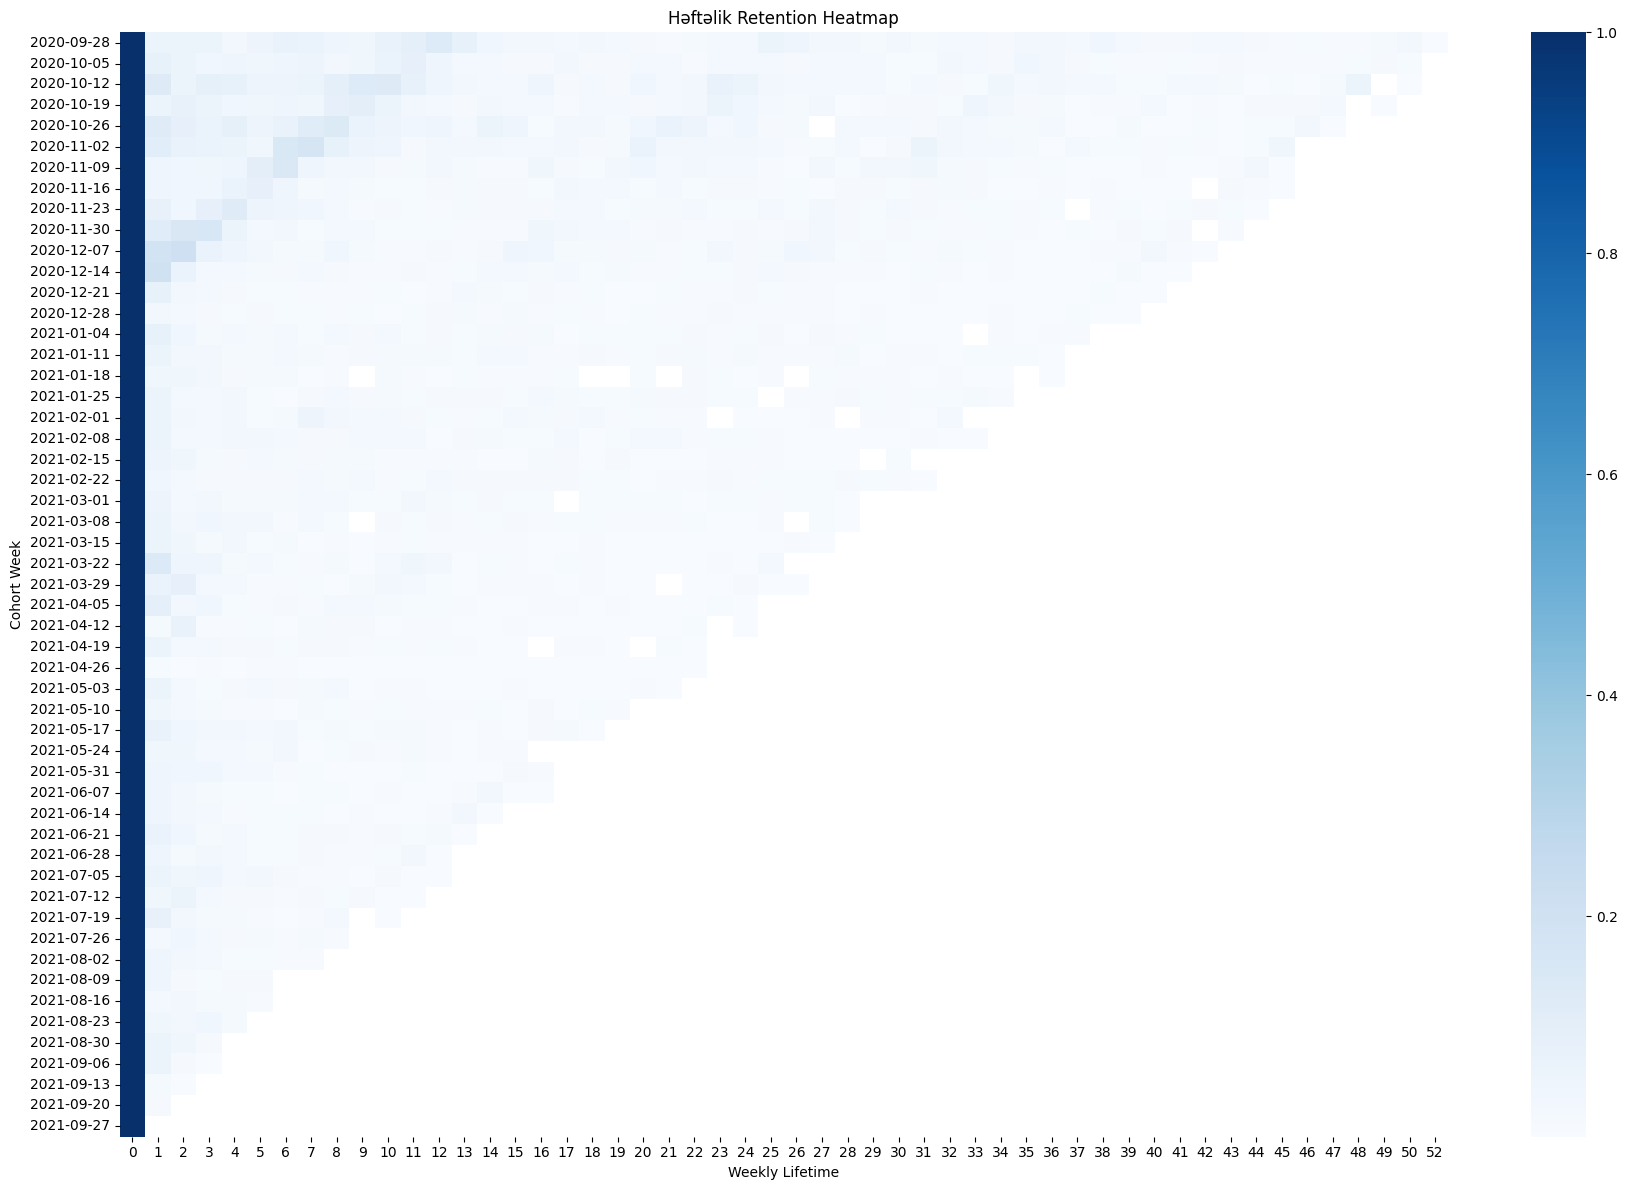

In [192]:
retention_plot = retention_matrix.copy()

# Tarixləri sadə formata salırıq
retention_plot.index = pd.to_datetime(
    retention_plot.index
).strftime('%Y-%m-%d')

plt.figure(figsize=(18, 12))

sns.heatmap(
    retention_plot,
    cmap='Blues',
    annot=False
)

plt.title('Həftəlik Retention Heatmap')
plt.xlabel('Weekly Lifetime')
plt.ylabel('Cohort Week')

plt.tight_layout()
plt.show()

### Həftəlik Retention Heatmap nəticəsinin şərhi

Heatmap hər həftəlik cohort-un ilk alışdan sonrakı həftələrdə retention səviyyəsini göstərir.

Qrafikdə ilk həftələrdən sonra retention-un ümumilikdə aşağı səviyyədə olduğu görünür. Bu, ilk alış edən müştərilərin yalnız kiçik bir hissəsinin sonrakı həftələrdə yenidən aktiv olduğunu göstərir.

Bəzi cohort-larda müəyyən həftələrdə retention-un digər həftələrə nisbətən yüksəldiyi müşahidə olunur. Bu, əvvəlki həftədə alış etməyən bəzi müştərilərin daha sonrakı həftədə yenidən geri qayıtması ilə bağlı ola bilər.

Ümumilikdə nəticə müştərilərin ilk alışdan sonra saxlanılmasının zəif olduğunu və retention-un artırılması üçün təkrar alışları təşviq edən tədbirlərə ehtiyac ola biləcəyini göstərir.

### Task 19 — Churn Rate

Churn rate müştərilərin başlanğıc cohort-dan müəyyən müddət sonra aktiv olmayan hissəsini göstərir.

Retention rate aktiv qalan müştərilərin payını göstərdiyi üçün churn rate `1 - retention_rate` formulası ilə hesablanır.

Formula:

`churn_rate = 1 - retention_rate`

In [195]:
weekly_active_customers['churn_rate'] = (1 - weekly_active_customers['retention_rate'])

In [196]:
weekly_active_customers[['cohort_week', 'weekly_lifetime', 'retention_rate', 'churn_rate']].head(10)

,cohort_week,weekly_lifetime,retention_rate,churn_rate
0,2020-09-28,0,1.000000,0.000000
1,2020-09-28,1,0.057214,0.942786
2,2020-09-28,2,0.062189,0.937811
3,2020-09-28,3,0.062189,0.937811
4,2020-09-28,4,0.034826,0.965174
5,2020-09-28,5,0.052239,0.947761
6,2020-09-28,6,0.072139,0.927861
7,2020-09-28,7,0.067164,0.932836
8,2020-09-28,8,0.049751,0.950249
9,2020-09-28,9,0.039801,0.960199


### Churn rate nəticəsinin şərhi

Retention və churn göstəriciləri birlikdə yoxlanıldı.

`weekly_lifetime = 0` zamanı retention 100%, churn isə 0%-dir. Bunun səbəbi həmin həftənin cohort-un başlanğıc həftəsi olmasıdır.

Məsələn, `2020-09-28` cohort-unda 1 həftə sonra retention təxminən 5.72%, churn isə təxminən 94.28% olmuşdur.

4 həftə sonra retention təxminən 3.48%-ə düşdüyü üçün churn təxminən 96.52%-ə yüksəlmişdir.

Ümumilikdə retention aşağı olduqda churn yüksək olur, çünki churn `1 - retention` formulası ilə hesablanır.

### Churn matrix yaradılması

Həftəlik churn nəticələrini cohort və lifetime üzrə müqayisə etmək üçün pivot table yaradılır.

Sətirlərdə `cohort_week`, sütunlarda `weekly_lifetime`, xanaların daxilində isə `churn_rate` göstərilir.

In [198]:
churn_matrix = weekly_active_customers.pivot(index='cohort_week',columns='weekly_lifetime',values='churn_rate')

In [199]:
churn_matrix

weekly_lifetime,0,1,2,3,4,5,6,7,8,9,...,42,43,44,45,46,47,48,49,50,52
cohort_week,,,,,,,,,,,,,,,,,,,,,
2020-09-28,0.0,0.942786,0.937811,0.937811,0.965174,0.947761,0.927861,0.932836,0.950249,0.960199,...,0.972637,0.977612,0.985075,0.992537,0.990050,0.992537,0.992537,0.982587,0.965174,0.997512
2020-10-05,0.0,0.920635,0.938776,0.961451,0.950113,0.956916,0.950113,0.947846,0.965986,0.959184,...,0.993197,0.986395,0.993197,0.995465,0.993197,0.995465,0.990930,0.984127,0.990930,NaN
2020-10-12,0.0,0.871345,0.938596,0.912281,0.918129,0.947368,0.947368,0.944444,0.909357,0.868421,...,0.976608,0.982456,0.997076,0.988304,0.997076,0.982456,0.941520,NaN,0.997076,NaN
2020-10-19,0.0,0.944584,0.921914,0.939547,0.962217,0.959698,0.952141,0.959698,0.914358,0.899244,...,0.992443,0.997481,0.987406,0.987406,0.984887,0.979849,NaN,0.997481,NaN,NaN
2020-10-26,0.0,0.882114,0.914634,0.934959,0.910569,0.947154,0.926829,0.886179,0.865854,0.934959,...,0.991870,0.995935,0.991870,0.991870,0.971545,0.995935,NaN,NaN,NaN,NaN
2020-11-02,0.0,0.889930,0.927400,0.936768,0.941452,0.957845,0.847775,0.826698,0.918033,0.948478,...,0.995316,0.997658,0.988290,0.960187,NaN,NaN,NaN,NaN,NaN,NaN
2020-11-09,0.0,0.949355,0.961271,0.959285,0.954320,0.895730,0.853029,0.949355,0.969215,0.971202,...,0.997021,0.993049,0.970209,0.999007,NaN,NaN,NaN,NaN,NaN,NaN
2020-11-16,0.0,0.955224,0.963516,0.963516,0.932007,0.915423,0.951907,0.981758,0.980100,0.981758,...,NaN,0.986733,0.995025,0.998342,NaN,NaN,NaN,NaN,NaN,NaN
2020-11-23,0.0,0.925000,0.961364,0.915909,0.879545,0.947727,0.954545,0.961364,0.975000,0.995455,...,0.986364,0.990909,0.997727,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Churn matrix nəticəsinin şərhi

Churn matrix hər həftəlik cohort-un müxtəlif `weekly_lifetime` dövrlərində aktiv olmayan müştəri payını göstərir.

Sətirlərdə `cohort_week`, sütunlarda `weekly_lifetime`, xanaların daxilində isə `churn_rate` yerləşir.

`weekly_lifetime = 0` zamanı churn rate 0%-dir, çünki bu cohort-un başlanğıc həftəsidir.

Məsələn, `2020-09-28` cohort-unda 1 həftə sonra churn təxminən 94.28%, 4 həftə sonra isə təxminən 96.52% olmuşdur.

Ümumilikdə churn göstəricilərinin yüksək olması ilk alışdan sonra müştərilərin böyük hissəsinin sonrakı həftələrdə aktiv olmadığını göstərir.

### Churn heatmap

Churn göstəricilərini cohort və lifetime üzrə daha rahat müqayisə etmək üçün churn matrix heatmap vasitəsilə vizuallaşdırılır.

Daha tünd rəng daha yüksək churn rate, daha açıq rəng isə daha aşağı churn rate göstərir.

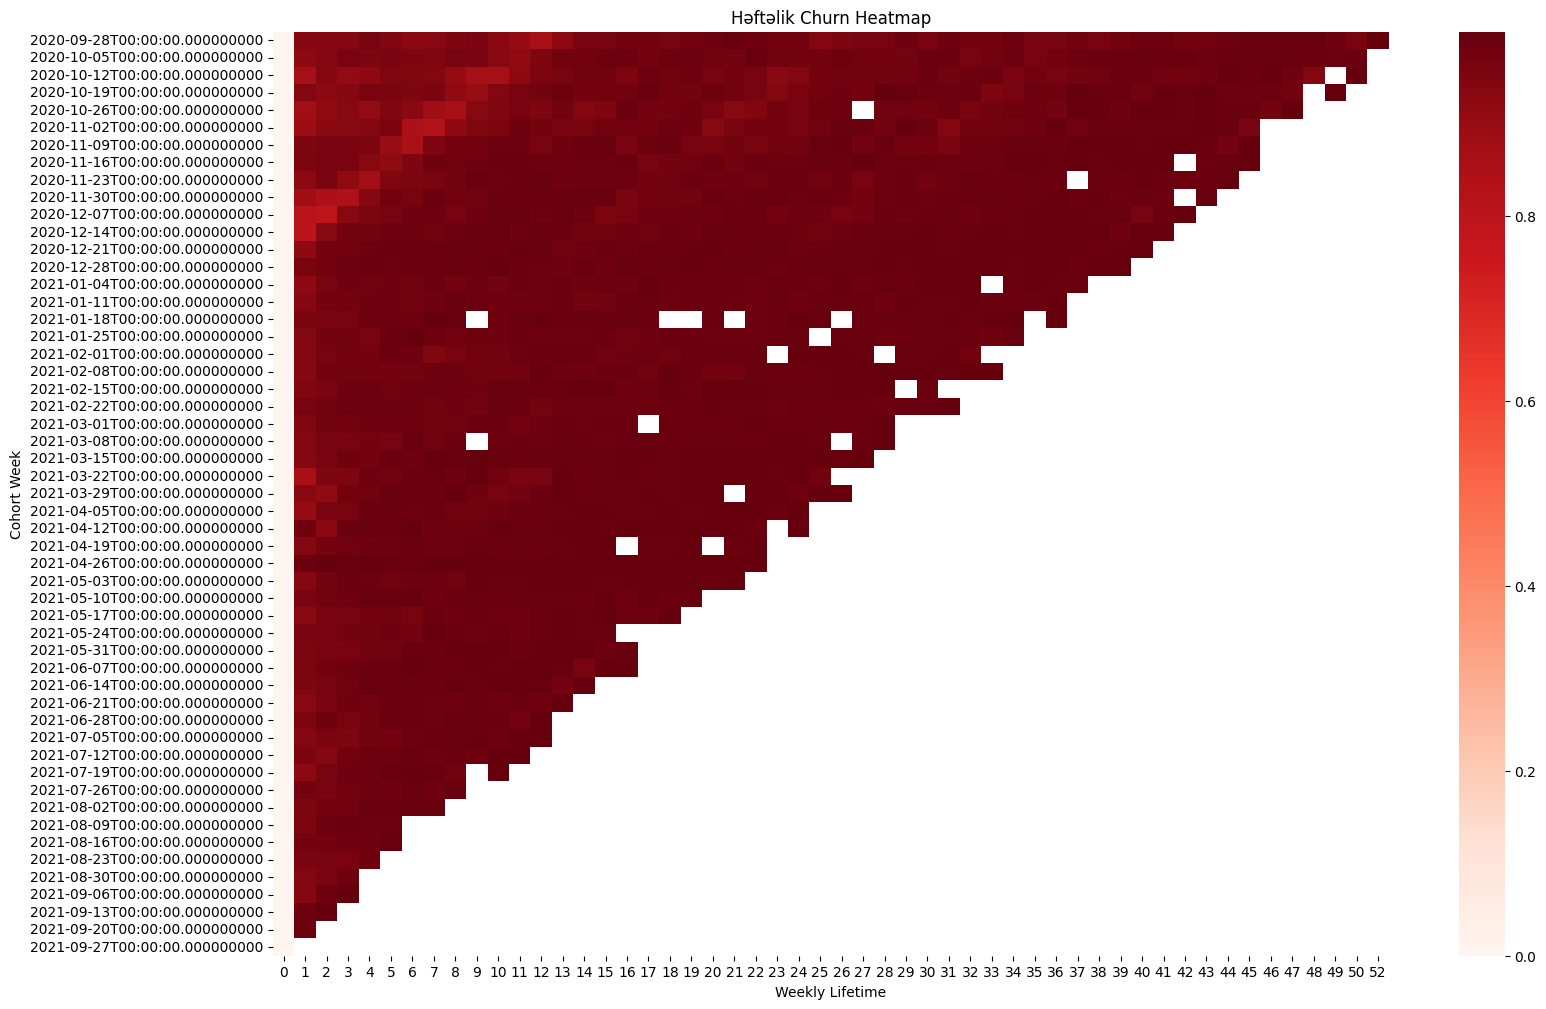

In [200]:
plt.figure(figsize=(18, 12))

sns.heatmap(
    churn_matrix,
    cmap='Reds',
    annot=False
)

plt.title('Həftəlik Churn Heatmap')
plt.xlabel('Weekly Lifetime')
plt.ylabel('Cohort Week')

plt.show()

### Həftəlik Churn Heatmap nəticəsinin şərhi

Churn heatmap həftəlik cohort-lar üzrə müştərilərin müxtəlif lifetime dövrlərində aktiv olmayan hissəsini göstərir.

`weekly_lifetime = 0` zamanı churn 0%-dir, çünki bu cohort-un başlanğıc həftəsidir.

İlk həftədən sonra əksər cohort-larda churn göstəricisinin yüksək olduğu müşahidə olunur. Heatmap-də tünd qırmızı sahələrin üstünlük təşkil etməsi müştərilərin böyük hissəsinin sonrakı həftələrdə aktiv olmadığını göstərir.

Məsələn, `2020-09-28` cohort-unda bir həftə sonra churn təxminən 94.28%, dörd həftə sonra isə təxminən 96.52% olmuşdur.

Qrafikin sağ tərəfindəki ağ üçbucaq sahə daha yeni cohort-ların həmin lifetime həftələrinə hələ çatmadığını göstərir və `NaN` dəyərlərinə uyğundur.

Ümumilikdə, aşağı retention nəticələri ilə uyğun olaraq churn səviyyəsinin yüksək olduğu müşahidə edilir.

## 4. Yekun nəticələr

### Task 20. Nəticələrin şərhi

Aylıq cohort-lar, ARPU, weekly retention və churn nəticələrinə əsasən əsas müşahidələrinizi yazın. Analizdən çıxan nəticələrə uyğun qısa biznes tövsiyələri hazırlayın.

## Task 20 — Yekun nəticələr və biznes tövsiyələri

Aparılan cohort analysis nəticəsində müştərilərin ilk alış dövründən sonra davranışı, gətirdikləri revenue, ARPU, həftəlik retention və churn göstəriciləri təhlil edildi.

### 1. Aylıq cohort nəticələri

Aylıq cohort-lar arasında nəzərəçarpacaq fərqlər müşahidə edildi.

`2020-12` cohort-u həm unikal müştəri, həm unikal sifariş, həm də ümumi revenue baxımından ən yüksək nəticəni göstərdi.

Bu cohort-da:
- 14 020 unikal müştəri,
- 35 055 unikal sifariş,
- təxminən 73.36 milyon total revenue

müşahidə edildi.

`2021-03` və `2021-04` cohort-larında da nisbətən yüksək göstəricilər qeydə alındı.

Bununla yanaşı, daha yeni cohort-ların ümumi revenue və sifariş göstəricilərinin aşağı olması onların analiz dövründə daha az müddət müşahidə olunması ilə də əlaqəli ola bilər. Buna görə fərqli cohort-ların total göstəricilərini müqayisə edərkən cohort-un nə qədər müddət aktiv olduğu nəzərə alınmalıdır.

### 2. ARPU nəticələri

ARPU bir aktiv müştəriyə düşən orta revenue göstəricisidir.

Analiz zamanı ARPU-nun cohort və lifetime üzrə sabit olmadığı, bəzi dövrlərdə nəzərəçarpacaq şəkildə yüksəldiyi görüldü.

Məsələn:
- `2020-10` cohort-u üçün lifetime 2-də ARPU təxminən 9730,
- `2021-06` cohort-u üçün lifetime 2-də təxminən 9294,
- `2021-07` cohort-u üçün lifetime 1-də təxminən 9204 olmuşdur.

Yüksək ARPU həmin dövrdə aktiv olan müştərilərin orta hesabla daha çox revenue gətirdiyini göstərir. Lakin yüksək ARPU həmişə çox sayda müştəri olduğu demək deyil. Bəzi hallarda az sayda, lakin yüksək məbləğdə alış edən müştərilər ARPU-nu yüksəldə bilər.

### 3. Həftəlik retention nəticələri

Həftəlik retention analysis göstərdi ki, müştərilərin böyük hissəsi ilk alışdan sonrakı həftələrdə yenidən aktiv olmur.

`weekly_lifetime = 0` zamanı retention 100%-dir, çünki bu cohort-un başlanğıc həftəsidir.

İlk həftədən sonra isə retention göstəricilərində ciddi azalma müşahidə olunur.

Məsələn, `2020-09-28` cohort-u üçün:
- başlanğıcda 402 müştəri var idi,
- 1 həftə sonra 23 müştəri aktiv olub → retention təxminən 5.72%,
- 2 həftə sonra 25 müştəri aktiv olub → retention təxminən 6.22%,
- 4 həftə sonra 14 müştəri aktiv olub → retention təxminən 3.48%.

Bu nəticə müştərilərin ilk alışdan sonra geri qaytarılmasının əsas inkişaf sahələrindən biri olduğunu göstərir.

### 4. Churn nəticələri

Churn rate bu analizdə `1 - retention` kimi hesablandı və həmin həftədə aktiv olmayan müştərilərin payını göstərir.

Retention aşağı olduğu üçün sonrakı həftələrdə churn göstəricilərinin yüksək olduğu müşahidə edildi.

Məsələn, `2020-09-28` cohort-u üçün:
- 1 həftə sonra churn təxminən 94.28%,
- 4 həftə sonra isə təxminən 96.52% olmuşdur.

Bu nəticələr ilk alışdan sonra müştərilərin böyük hissəsinin sonrakı həftələrdə yenidən aktiv olmadığını göstərir.

Qeyd: Buradakı churn göstəricisi həmin həftədə aktiv olmayan müştəri payını göstərir və müştərinin biznesi həmişəlik tərk etdiyini mütləq ifadə etmir. Müştəri sonrakı həftələrdə yenidən aktiv ola bilər.

## Biznes tövsiyələri

1. **İlk alışdan sonrakı dövrə fokuslanmaq**

Retention-un ən böyük azalması ilk alışdan sonrakı həftələrdə müşahidə olunduğu üçün müştəri ilə ilk alışdan dərhal sonra yenidən əlaqə qurmaq vacibdir.

Endirim kuponları, fərdiləşdirilmiş məhsul təklifləri və follow-up kampaniyaları təkrar alışları artıra bilər.

2. **2020-12 cohort-unun səbəbini araşdırmaq**

`2020-12` cohort-u digər aylardan ciddi şəkildə fərqləndiyi üçün bu dövrdə həyata keçirilmiş kampaniyalar, mövsümi satışlar və digər biznes faktorları ayrıca araşdırılmalıdır.

Əgər uğurun konkret kampaniya və ya strategiya ilə əlaqəli olduğu müəyyən edilərsə, həmin yanaşma digər dövrlərdə də tətbiq oluna bilər.

3. **Yüksək ARPU göstərən cohort-ları ayrıca analiz etmək**

Yüksək ARPU göstərən müştəri qruplarının hansı məhsulları aldığı, hansı kateqoriyalara üstünlük verdiyi və hansı payment method-dan istifadə etdiyi araşdırıla bilər.

Bu müştərilər üçün fərdiləşdirilmiş kampaniyalar və loyalty proqramları yaradıla bilər.

4. **Retention və ARPU birlikdə qiymətləndirilməlidir**

Yalnız yüksək revenue və ya yüksək ARPU kifayət deyil. Biznes üçün həm yüksək gəlir gətirən, həm də uzun müddət aktiv qalan müştərilər daha dəyərlidir.

Buna görə gələcək analizlərdə ARPU, retention və cohort lifetime göstəricilərinin birlikdə qiymətləndirilməsi məqsədəuyğundur.

### Ümumi nəticə

Analiz göstərir ki, bəzi cohort-lar yüksək revenue və ARPU yaratmasına baxmayaraq, həftəlik retention ümumilikdə aşağıdır və ilk alışdan sonra müştəri aktivliyində ciddi azalma müşahidə olunur.

Əsas biznes prioriteti yeni müştəri cəlb etməklə yanaşı, mövcud müştərilərin təkrar alışını artırmaq və onları daha uzun müddət aktiv saxlamaq olmalıdır.

<!-- Cavabınızı burada yazın. -->